# **Bối cảnh bài toán**
Trong ngành bán lẻ, nhu cầu mua sắm của khách hàng thường biến động mạnh theo thời gian, đặc biệt là theo mùa vụ và các dịp lễ lớn. Những thời điểm như **Christmas, Thanksgiving hoặc các chương trình khuyến mãi lớn** có thể khiến doanh thu tăng đột biến so với các tuần thông thường. Ngược lại, sau những giai đoạn mua sắm cao điểm, doanh thu có thể giảm đáng kể.

Đối với các doanh nghiệp bán lẻ quy mô lớn như Walmart, việc không dự đoán được những biến động này có thể gây ra nhiều rủi ro trong hoạt động kinh doanh. Nếu doanh nghiệp dự trữ hàng hóa quá ít trong các giai đoạn nhu cầu cao, họ có thể mất cơ hội bán hàng và doanh thu. Ngược lại, nếu tồn kho quá nhiều khi nhu cầu giảm, doanh nghiệp sẽ phải đối mặt với chi phí lưu kho và nguy cơ hàng hóa tồn đọng.

Do đó, dự báo doanh thu trong tương lai đóng vai trò quan trọng trong việc hỗ trợ doanh nghiệp lập kế hoạch kinh doanh, quản lý tồn kho và đưa ra các quyết định chiến lược. Dự báo chính xác giúp doanh nghiệp chủ động trong việc chuẩn bị hàng hóa, phân bổ nguồn lực và triển khai các chiến dịch marketing phù hợp với từng giai đoạn.


---


# **Mục tiêu nghiên cứu**
Mục tiêu của nghiên cứu này là xây dựng các mô hình dự báo doanh thu tuần dựa trên dữ liệu lịch sử của Walmart. Cụ thể, nghiên cứu tập trung vào việc:
*  Phân tích đặc điểm dữ liệu bán hàng theo thời gian
*  Xác định các yếu tố có thể ảnh hưởng đến doanh thu
*  Xây dựng và so sánh nhiều mô hình dự báo khác nhau
*  Lựa chọn mô hình có độ chính xác tốt nhất để dự báo doanh thu trong tương lai

Kết quả dự báo có thể hỗ trợ doanh nghiệp:
*  Ước lượng nhu cầu bán hàng trong các tuần tiếp theo
*  Chuẩn bị kế hoạch tồn kho phù hợp
*  Hỗ trợ lập kế hoạch doanh thu và chiến lược kinh doanh.

---


# **Phương pháp tiếp cận**

Để giải quyết bài toán dự báo doanh thu, nghiên cứu xây dựng một pipeline phân tích dữ liệu gồm các bước chính sau:

1. **Khám phá và phân tích dữ liệu (EDA)**

Dữ liệu bán hàng được phân tích để tìm hiểu phân phối doanh thu, xu hướng theo thời gian, sự khác biệt giữa tuần lễ và tuần thường, cũng như mối quan hệ giữa doanh thu và các biến kinh tế như nhiệt độ, CPI hoặc tỷ lệ thất nghiệp.

2. **Lựa chọn các bộ phận kinh doanh quan trọng**

Do dữ liệu bao gồm nhiều bộ phận sản phẩm khác nhau, nghiên cứu tập trung vào **ba Department** có tổng doanh thu cao nhất để xây dựng mô hình dự báo chi tiết.

3. **Xây dựng đặc trưng cho mô hình**

Các đặc trưng thời gian và đặc trưng chuỗi thời gian được tạo ra nhằm cải thiện khả năng dự báo, bao gồm:
*  Đặc trưng thời gian (week, month, quarter, year)
*  Đặc trưng độ trễ (lag features)
*  Đặc trưng trung bình trượt (rolling statistics)
*  Đặc trưng sai phân (difference features)
*  Đặc trưng ngày lễ và chương trình khuyến mãi.

4. **Xây dựng và so sánh nhiều mô hình dự báo**

Ba mô hình dự báo được áp dụng và so sánh:
*  **Holt‑Winters**
*  **ARIMA**
*  **XGBoost**

Các mô hình được đánh giá bằng các chỉ số sai số như **MAE, RMSE và MAPE**.

5. **Lựa chọn mô hình tốt nhất và dự báo doanh thu tương lai**

Sau khi so sánh hiệu suất của các mô hình, mô hình có sai số thấp nhất sẽ được sử dụng để dự báo doanh thu cho tập dữ liệu kiểm tra.

6. **Hỗ trợ ra quyết định tồn kho**

Dựa trên kết quả dự báo, nghiên cứu phân loại các tuần theo mức nhu cầu dự kiến (thấp, trung bình, cao) nhằm cung cấp thông tin tham khảo cho việc điều chỉnh mức tồn kho trong tương lai.

---

# **Ý nghĩa thực tiễn của nghiên cứu**

Kết quả của nghiên cứu có thể mang lại một số lợi ích cho doanh nghiệp bán lẻ:
*  Hỗ trợ dự báo doanh thu trong tương lai
*  Giúp doanh nghiệp chuẩn bị kế hoạch tồn kho hợp lý
*  Giảm thiểu rủi ro thiếu hàng hoặc tồn kho dư thừa
*  Cung cấp thông tin phục vụ việc lập kế hoạch kinh doanh và marketing.



# **Phase 1: THU THẬP & HIỂU DỮ LIỆU**

### **Bước 1: Lấy dữ liệu từ Kaggle**

In [ ]:
import kagglehub, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal   import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools  import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
print("Import xong.")

Import xong.


In [ ]:
dataset_path = kagglehub.dataset_download("aslanahmedov/walmart-sales-forecast")
print("Path:", dataset_path)
print("Files:", os.listdir(dataset_path))

train    = pd.read_csv(os.path.join(dataset_path, "train.csv"))
test     = pd.read_csv(os.path.join(dataset_path, "test.csv"))
features = pd.read_csv(os.path.join(dataset_path, "features.csv"))
stores   = pd.read_csv(os.path.join(dataset_path, "stores.csv"))

# Chuyen kieu Date ngay tu dau de dung xuyen suot
train['Date']    = pd.to_datetime(train['Date'])
test['Date']     = pd.to_datetime(test['Date'])
features['Date'] = pd.to_datetime(features['Date'])

print("\n--- Shape ---")
for name, df in [("train", train), ("test", test),
                 ("features", features), ("stores", stores)]:
    print(f"  {name:<10}: {df.shape}")

100%|██████████| 3.36M/3.36M [00:00<00:00, 94.5MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/aslanahmedov/walmart-sales-forecast/versions/1
Files: ['features.csv', 'train.csv', 'test.csv', 'stores.csv']

--- Shape ---
  train     : (421570, 5)
  test      : (115064, 4)
  features  : (8190, 12)
  stores    : (45, 3)


### **Bước 2: Khám phá dữ liệu - EDA sơ bộ trên tập train**

#### Tổng quan bộ dữ liệu

In [ ]:
df_eda = (train
          .merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
          .merge(stores,   on='Store',  how='left'))
df_eda['Year']  = df_eda['Date'].dt.year
df_eda['Month'] = df_eda['Date'].dt.month
df_eda['Week']  = df_eda['Date'].dt.isocalendar().week.astype(int)

print("=== THONG TIN CO BAN ===")
print(df_eda.info())
print("\n=== THONG KE MO TA ===")
display(df_eda.describe())
print("\n=== GIA TRI THIEU ===")
display(df_eda.isnull().sum())
print("\n=== SO DONG TRUNG LAP ===", df_eda.duplicated().sum())

=== THONG TIN CO BAN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object      

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Year,Month,Week
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,60.090059,3.361027,2590.074819,879.974298,468.087665,1083.132268,1662.772385,171.201947,7.960289,136727.915739,2010.968591,6.449510,25.826762
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,34875.000000,2010.000000,1.000000,1.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,93638.000000,2010.000000,4.000000,14.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000,140167.000000,2011.000000,6.000000,26.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000,202505.000000,2012.000000,9.000000,38.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000,2012.000000,12.000000,52.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,6052.385934,5084.538801,5528.873453,3894.529945,4207.629321,39.159276,1.863296,60980.583328,0.796876,3.243217,14.151887



=== GIA TRI THIEU ===


,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0



=== SO DONG TRUNG LAP === 0


#### Phân phối doanh thu

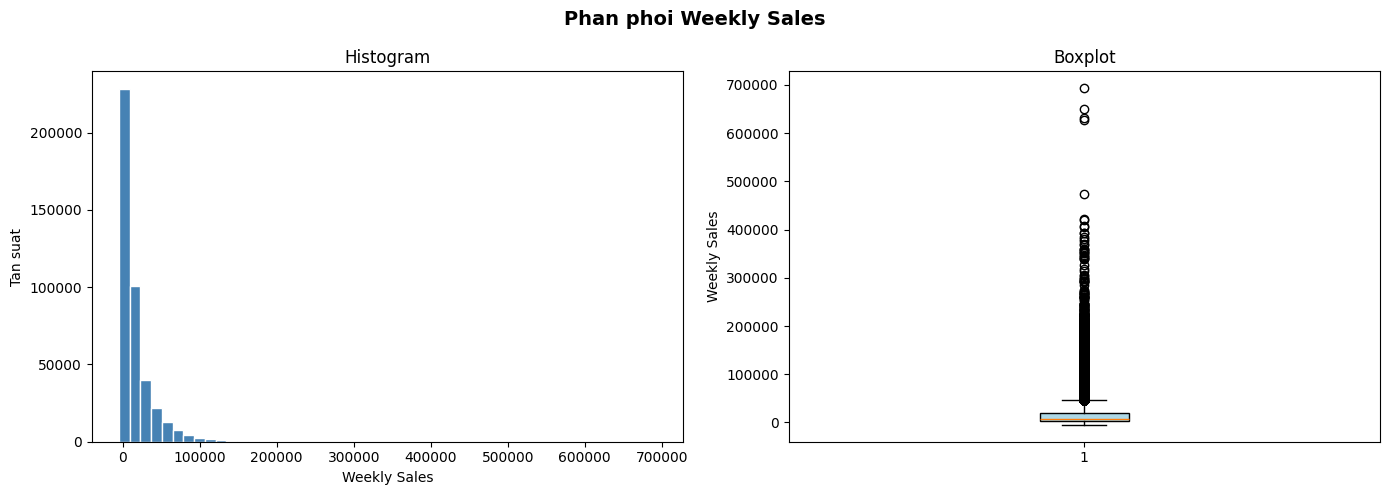

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phan phoi Weekly Sales", fontsize=14, fontweight='bold')
axes[0].hist(df_eda['Weekly_Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set(title="Histogram", xlabel="Weekly Sales", ylabel="Tan suat")
axes[1].boxplot(df_eda['Weekly_Sales'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set(title="Boxplot", ylabel="Weekly Sales")
plt.tight_layout(); plt.show()

#### Biến động theo thời gian

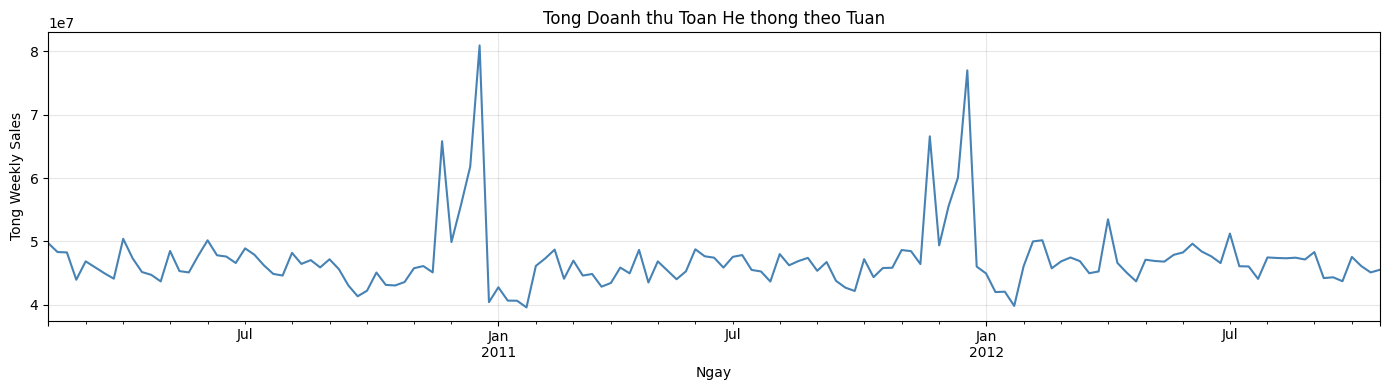

In [ ]:
weekly_total = df_eda.groupby('Date')['Weekly_Sales'].sum()
plt.figure(figsize=(14, 4))
weekly_total.plot(color='steelblue', linewidth=1.5)
plt.title("Tong Doanh thu Toan He thong theo Tuan")
plt.xlabel("Ngay"); plt.ylabel("Tong Weekly Sales")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

#### Tác động của ngày lễ

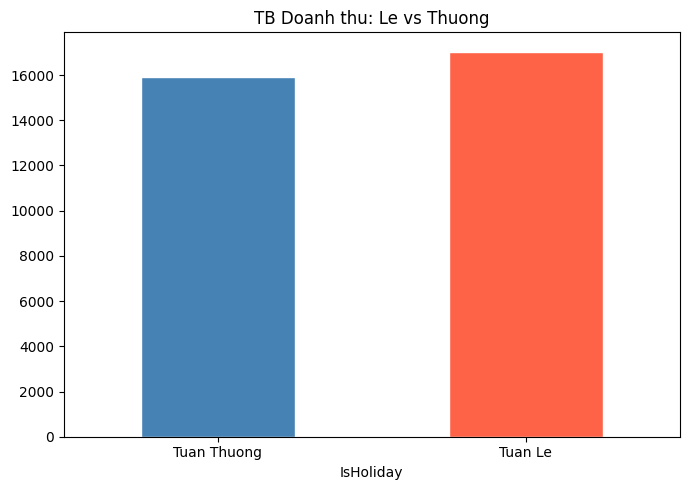


--- So luong ngay thuong va ngay le ---
  So tuan thuong: 391909
  So tuan le    : 29661


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

df_eda.groupby('IsHoliday')['Weekly_Sales'].mean().plot(
    kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set(title="TB Doanh thu: Le vs Thuong",
       xticklabels=['Tuan Thuong', 'Tuan Le'])
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n--- So luong ngay thuong va ngay le ---")
holiday_counts = df_eda['IsHoliday'].value_counts()
print(f"  So tuan thuong: {holiday_counts.get(False, 0)}")
print(f"  So tuan le    : {holiday_counts.get(True, 0)}")

#### Tương quan giữa các biến vĩ mô với biến Weekly_Sales

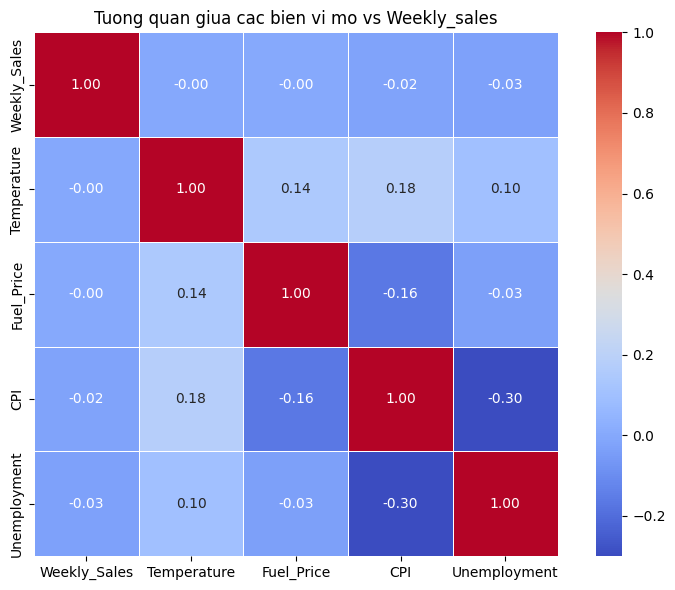

In [ ]:
corr = df_eda[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']].corr()

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Tuong quan giua cac bien vi mo vs Weekly_sales")
plt.tight_layout()
plt.show()

#### Doanh thu theo tháng - năm

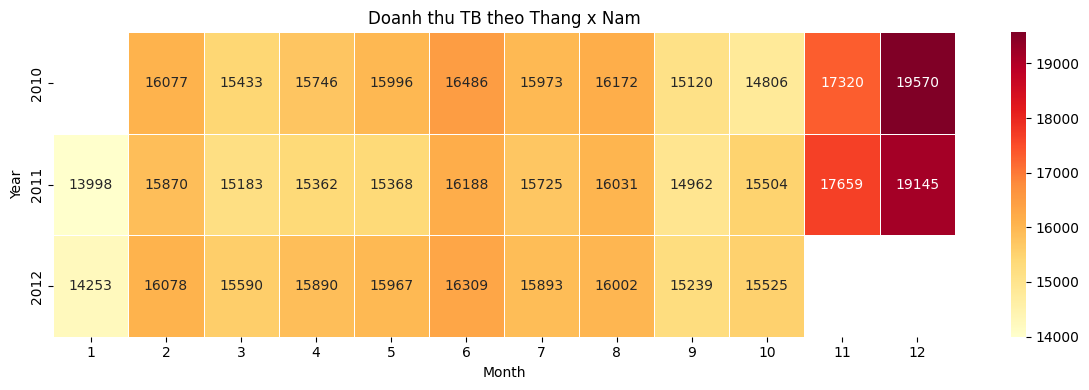

In [ ]:
heatmap_data = df_eda.groupby(['Year','Month'])['Weekly_Sales'].mean().unstack()
plt.figure(figsize=(12, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title("Doanh thu TB theo Thang x Nam")
plt.tight_layout(); plt.show()

### **Bước 3: Lựa chọn ngành hàng**

> Chọn top 3

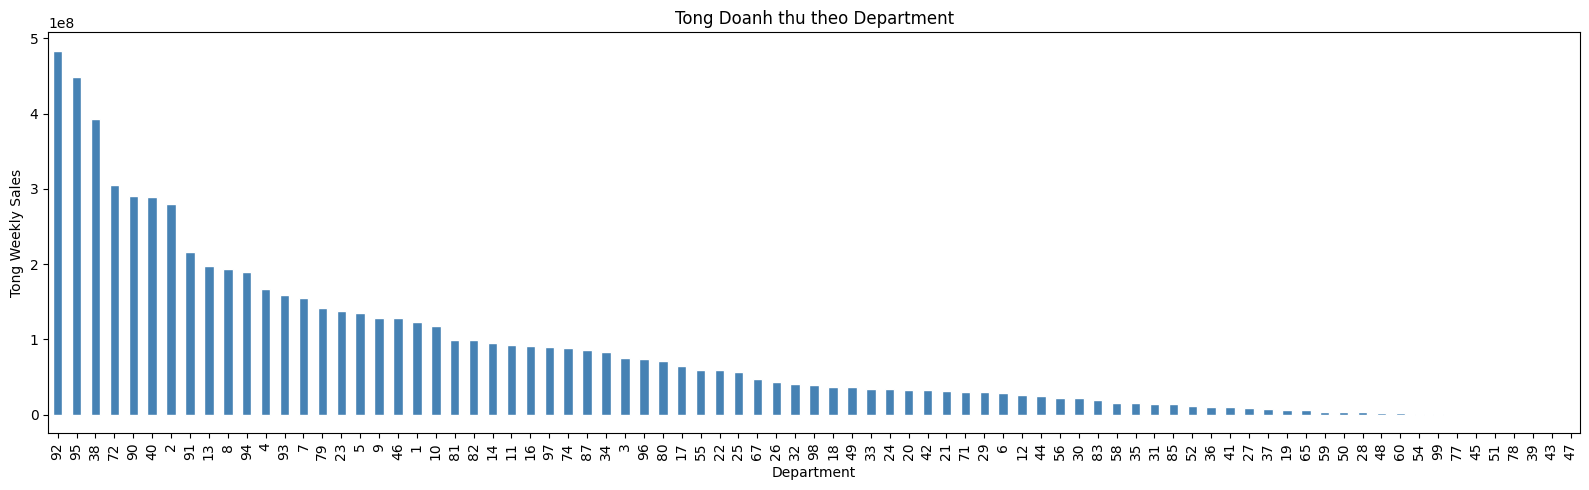

Top 3 Departments: [92, 95, 38]
Chiem 19.7% tong doanh thu

  Dept 92: Train=143w | Test=39w | Revenue=483,943,342 (7.2%)
  Dept 95: Train=143w | Test=39w | Revenue=449,320,163 (6.7%)
  Dept 38: Train=143w | Test=39w | Revenue=393,118,137 (5.8%)


In [ ]:
dept_sales_all = (df_eda.groupby('Dept')['Weekly_Sales']
                        .sum()
                        .sort_values(ascending=False))

# Bieu do bar chart tat ca dept
plt.figure(figsize=(16, 5))
dept_sales_all.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Tong Doanh thu theo Department")
plt.xlabel("Department"); plt.ylabel("Tong Weekly Sales")
plt.xticks(rotation=90); plt.tight_layout(); plt.show()

# Chon Top 3
TOP_3_DEPTS  = dept_sales_all.head(3).index.tolist()
top3_pct     = dept_sales_all[TOP_3_DEPTS].sum() / dept_sales_all.sum() * 100
print(f"Top 3 Departments: {TOP_3_DEPTS}")
print(f"Chiem {top3_pct:.1f}% tong doanh thu\n")

for dept in TOP_3_DEPTS:
    n_tr = train[train['Dept'] == dept]['Date'].nunique()
    n_te = test[test['Dept'] == dept]['Date'].nunique()
    rev  = dept_sales_all[dept]
    pct  = rev / dept_sales_all.sum() * 100
    print(f"  Dept {dept}: Train={n_tr}w | Test={n_te}w | "
          f"Revenue={rev:,.0f} ({pct:.1f}%)")

# **PHASE 2: TIỀN XỬ LÝ DỮ LIỆU**

### **Khai báo dùng chung**

In [ ]:
FEATURE_COLS  = [
    'week', 'month', 'quarter', 'year',
    'lag_1', 'lag_2', 'lag_4',
    'rolling_mean_4', 'rolling_mean_8',
    'rolling_max_4',  'rolling_max_8',
    'diff_1', 'diff_2', 'diff_4',
    'is_christmas', 'is_thanksgiving', 'is_superbowl', 'is_laborday',
    'total_markdown', 'markdown_count',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday'
]
TARGET_COL    = 'Weekly_Sales'
MARKDOWN_COLS = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

# --- State dict: luu ket qua tung dept de dung lai o cac cell sau ---
STATE = {dept: {} for dept in TOP_3_DEPTS}


def add_time_holiday_promo_features(df_agg):
    """Them time, holiday, promotion features vao df da aggregate."""
    df_agg['week']    = df_agg.index.isocalendar().week.astype(int)
    df_agg['month']   = df_agg.index.month
    df_agg['quarter'] = df_agg.index.quarter
    df_agg['year']    = df_agg.index.year

    df_agg['is_christmas']    = ((df_agg.index.month == 12) &
                                  (df_agg['week'] >= 51)).astype(int)
    df_agg['is_thanksgiving'] = ((df_agg.index.month == 11) &
                                  (df_agg['week'].isin([47, 48]))).astype(int)
    df_agg['is_superbowl']    = ((df_agg.index.month == 2) &
                                  (df_agg['week'].isin([5, 6, 7]))).astype(int)
    df_agg['is_laborday']     = ((df_agg.index.month == 9) &
                                  (df_agg['week'] <= 37)).astype(int)

    df_agg['total_markdown'] = df_agg[MARKDOWN_COLS].sum(axis=1)
    df_agg['markdown_count'] = (df_agg[MARKDOWN_COLS] > 0).sum(axis=1)
    return df_agg


def add_lag_rolling_diff_features(df_agg):
    """
    Them lag, rolling, diff features.
    Tat ca deu dung shift(1) truoc de tranh data leakage.
    """
    s = df_agg[TARGET_COL]

    df_agg['lag_1'] = s.shift(1)
    df_agg['lag_2'] = s.shift(2)
    df_agg['lag_4'] = s.shift(4)

    df_agg['rolling_mean_4'] = s.shift(1).rolling(window=4, min_periods=1).mean()
    df_agg['rolling_mean_8'] = s.shift(1).rolling(window=8, min_periods=1).mean()
    df_agg['rolling_max_4']  = s.shift(1).rolling(window=4, min_periods=1).max()
    df_agg['rolling_max_8']  = s.shift(1).rolling(window=8, min_periods=1).max()

    # diff sau do shift(1) -> tranh dung gia tri hien tai de tinh diff
    df_agg['diff_1'] = s.diff(1).shift(1)
    df_agg['diff_2'] = s.diff(2).shift(1)
    df_agg['diff_4'] = s.diff(4).shift(1)
    return df_agg


def adf_kpss_check(series, label=""):
    """
    Kiem tra tinh dung bang ADF + KPSS.
    Tra ve: (is_stationary: bool, adf_pval: float, kpss_pval: float)
    """
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC')
    kpss_stat, kpss_p, _, _     = kpss(series, regression='c', nlags='auto')

    adf_dung  = adf_p  < 0.05   # True = dung (ADF)
    kpss_dung = kpss_p >= 0.05  # True = dung (KPSS)

    if label:
        print(f"  [{label}]")
        print(f"    ADF  stat={adf_stat:7.4f}  p={adf_p:.4f}  "
              f"-> {'DUNG' if adf_dung else 'CHUA DUNG'}")
        print(f"    KPSS stat={kpss_stat:7.4f}  p={kpss_p:.4f}  "
              f"-> {'DUNG' if kpss_dung else 'CHUA DUNG'}")

    # Ca hai dong thuan moi ket luan chinh xac
    is_stationary = adf_dung and kpss_dung
    return is_stationary, adf_p, kpss_p


def find_d_order(series, max_d=2):
    """
    Tim d toi uu bang cach lay sai phan lan luot va kiem tra lai ADF+KPSS.
    Sau moi lan lay sai phan -> kiem tra lai -> neu dung thi dung lai.
    Dam bao d khong qua max_d de tranh over-differencing.
    Tra ve: (d_order: int, series_diff: pd.Series)
    """
    print("  Kiem tra tinh dung tung buoc:")
    current_series = series.dropna().copy()

    for d in range(0, max_d + 1):
        label       = f"Chuoi goc" if d == 0 else f"Sau diff bac {d}"
        is_stat, adf_p, kpss_p = adf_kpss_check(current_series, label=label)

        if is_stat:
            print(f"  => Chuoi DUNG sau d={d} lan sai phan. Chon d={d}.")
            return d, current_series

        if d < max_d:
            print(f"  => Chua dung, lay them sai phan bac {d+1}...")
            current_series = current_series.diff(1).dropna()

    print(f"  => Van chua dung sau {max_d} lan. Dung lai voi d={max_d}.")
    return max_d, current_series


def compute_metrics(y_true, y_pred, model_name=""):
    """Tinh RMSE, MAE, MAPE. In ra neu co model_name."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae    = np.mean(np.abs(y_true - y_pred))
    rmse   = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape   = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    if model_name:
        print(f"    {model_name:<28} MAE={mae:>12,.0f}  "
              f"RMSE={rmse:>12,.0f}  MAPE={mape:.2f}%")
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


def recursive_forecast_xgb(history, test_df, model, feature_cols):
    """
    Recursive forecasting cho XGBoost.
    Lag/rolling/diff duoc tinh dong tu history sau moi buoc
    -> tranh dung gia tri Weekly_Sales that (khong co trong tap test).
    """
    history     = list(history)
    predictions = []

    for i in range(len(test_df)):
        row  = test_df.iloc[i]
        feat = {
            'week'    : row['week'],
            'month'   : row['month'],
            'quarter' : row['quarter'],
            'year'    : row['year'],
            # Lag tinh dong tu history
            'lag_1'   : history[-1],
            'lag_2'   : history[-2],
            'lag_4'   : history[-4],
            # Rolling tinh dong tu history
            'rolling_mean_4' : np.mean(history[-4:]),
            'rolling_mean_8' : np.mean(history[-8:]),
            'rolling_max_4'  : np.max(history[-4:]),
            'rolling_max_8'  : np.max(history[-8:]),
            # Diff tinh dong tu history
            'diff_1'  : history[-1] - history[-2],
            'diff_2'  : history[-1] - history[-3],
            'diff_4'  : history[-1] - history[-5],
            # External features lay thang tu test_df (co san)
            'is_christmas'    : row['is_christmas'],
            'is_thanksgiving' : row['is_thanksgiving'],
            'is_superbowl'    : row['is_superbowl'],
            'is_laborday'     : row['is_laborday'],
            'total_markdown'  : row['total_markdown'],
            'markdown_count'  : row['markdown_count'],
            'Temperature'     : row['Temperature'],
            'Fuel_Price'      : row['Fuel_Price'],
            'CPI'             : row['CPI'],
            'Unemployment'    : row['Unemployment'],
            'IsHoliday'       : row['IsHoliday'],
        }
        X     = pd.DataFrame([feat])[feature_cols]
        y_hat = float(model.predict(X)[0])
        predictions.append(y_hat)
        history.append(y_hat)   # cap nhat history bang gia tri du bao

    return predictions


def classify_action(val, p25, p75):
    if val >= p75: return "CAO - Tang ton kho +20%"
    if val >= p25: return "TRUNG BINH - Giu ton kho hien tai"
    return "THAP - Giam ton kho -15%"


print("Constants & helpers da san sang.")
print(f"Top 3 Depts: {TOP_3_DEPTS}")
print(f"STATE keys : {list(STATE.keys())}")

Constants & helpers da san sang.
Top 3 Depts: [92, 95, 38]
STATE keys : [92, 95, 38]


### **Bước 4: Kiểm tra và xử lý missing value ở cột Markdown với 3 Dept**

In [ ]:
# ========== CHECK & FILL MISSING VALUE MARKDOWN ==========
print("=" * 60)
print("  KIEM TRA MISSING VALUE MARKDOWN - TRUOC AGGREGATE")
print("=" * 60)

# Check missing trên features gốc (trước aggregate)
print("\n--- Tren tap features goc (chua aggregate) ---")
for DEPT in TOP_3_DEPTS:
    df_raw = (train[train['Dept'] == DEPT]
              .merge(features, on=['Store','Date','IsHoliday'], how='left'))
    missing = df_raw[MARKDOWN_COLS].isnull().sum()
    total   = len(df_raw)
    print(f"\n  Dept {DEPT} (train, {total} dong):")
    for col, cnt in missing.items():
        pct = cnt / total * 100
        print(f"    {col:<12}: {cnt:>6,} missing  ({pct:.1f}%)")

# Check missing trên tập test
print("\n--- Tren tap test goc (chua aggregate) ---")
for DEPT in TOP_3_DEPTS:
    df_raw = (test[test['Dept'] == DEPT]
              .merge(features, on=['Store','Date','IsHoliday'], how='left'))
    missing = df_raw[MARKDOWN_COLS].isnull().sum()
    total   = len(df_raw)
    print(f"\n  Dept {DEPT} (test, {total} dong):")
    for col, cnt in missing.items():
        pct = cnt / total * 100
        print(f"    {col:<12}: {cnt:>6,} missing  ({pct:.1f}%)")

# ========== FILL 0 TRỰC TIẾP TRÊN features GỐC ==========
# Ly do: fillna truoc aggregate moi chinh xac
# NaN = khong co chuong trinh khuyen mai -> = 0
print("\n--- Fill 0 tren features goc ---")
missing_before = features[MARKDOWN_COLS].isnull().sum().sum()
features[MARKDOWN_COLS] = features[MARKDOWN_COLS].fillna(0)
missing_after  = features[MARKDOWN_COLS].isnull().sum().sum()
print(f"  Missing truoc fill : {missing_before:,}")
print(f"  Missing sau  fill  : {missing_after:,}")
print("  => Fill 0 hoan tat. Anh huong ca train va test (dung chung bang features)")

  KIEM TRA MISSING VALUE MARKDOWN - TRUOC AGGREGATE

--- Tren tap features goc (chua aggregate) ---

  Dept 92 (train, 6435 dong):
    MarkDown1   :  4,155 missing  (64.6%)
    MarkDown2   :  4,798 missing  (74.6%)
    MarkDown3   :  4,389 missing  (68.2%)
    MarkDown4   :  4,470 missing  (69.5%)
    MarkDown5   :  4,140 missing  (64.3%)

  Dept 95 (train, 6435 dong):
    MarkDown1   :  4,155 missing  (64.6%)
    MarkDown2   :  4,798 missing  (74.6%)
    MarkDown3   :  4,389 missing  (68.2%)
    MarkDown4   :  4,470 missing  (69.5%)
    MarkDown5   :  4,140 missing  (64.3%)

  Dept 38 (train, 6435 dong):
    MarkDown1   :  4,155 missing  (64.6%)
    MarkDown2   :  4,798 missing  (74.6%)
    MarkDown3   :  4,389 missing  (68.2%)
    MarkDown4   :  4,470 missing  (69.5%)
    MarkDown5   :  4,140 missing  (64.3%)

--- Tren tap test goc (chua aggregate) ---

  Dept 92 (test, 1755 dong):
    MarkDown1   :      3 missing  (0.2%)
    MarkDown2   :    471 missing  (26.8%)
    MarkDown3   :   

### **Bước 5: Aggregate + kiểm tra chất lượng**

In [ ]:
for DEPT in TOP_3_DEPTS:
    print(f"\n{'='*60}")
    print(f"  DEPT {DEPT} - Tien xu ly & Kiem tra chat luong")
    print(f"{'='*60}")

    # Loc theo dept, merge external data
    df = (train[train['Dept'] == DEPT]
          .copy()
          .merge(features, on=['Store','Date','IsHoliday'], how='left')
          .merge(stores,   on='Store', how='left')
          .sort_values('Date')
          .reset_index(drop=True))
    df.set_index('Date', inplace=True)

    # Aggregate theo tuan (tong hop tat ca cua hang)
    df_agg = df.groupby(df.index).agg({
        TARGET_COL   : 'sum',
        'IsHoliday'  : 'max',
        'Temperature': 'mean',
        'Fuel_Price' : 'mean',
        'CPI'        : 'mean',
        'Unemployment': 'mean',
        **{c: 'sum' for c in MARKDOWN_COLS},
    })

    # Kiem tra gaps
    full_range   = pd.date_range(df_agg.index.min(),
                                 df_agg.index.max(), freq='W-FRI')
    missing_wks  = full_range.difference(df_agg.index)
    dupl         = df_agg.index.duplicated().sum()
    n_outlier    = (np.abs((df_agg[TARGET_COL] -
                            df_agg[TARGET_COL].mean()) /
                           df_agg[TARGET_COL].std()) > 3).sum()

    print(f"  So tuan sau aggregate : {len(df_agg)}")
    print(f"  Tuan bi thieu         : {len(missing_wks)}")
    print(f"  Dong trung lap        : {dupl}")
    print(f"  Outlier (|z|>3)       : {n_outlier}")
    print(f"  Khoang thoi gian      : "
          f"{df_agg.index.min().date()} -> {df_agg.index.max().date()}")
    display(df_agg.head())

    STATE[DEPT]['df_agg'] = df_agg


  DEPT 92 - Tien xu ly & Kiem tra chat luong
  So tuan sau aggregate : 143
  Tuan bi thieu         : 0
  Dong trung lap        : 0
  Outlier (|z|>3)       : 1
  Khoang thoi gian      : 2010-02-05 -> 2012-10-26


,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
Date,,,,,,,,,,,
2010-02-05,3781162.87,False,34.037333,2.717844,167.730885,8.619311,0.0,0.0,0.0,0.0,0.0
2010-02-12,3443837.30,True,34.151333,2.694022,167.825608,8.619311,0.0,0.0,0.0,0.0,0.0
2010-02-19,3312991.71,False,37.719778,2.672067,167.871686,8.619311,0.0,0.0,0.0,0.0,0.0
2010-02-26,3204210.06,False,39.243556,2.683933,167.909657,8.619311,0.0,0.0,0.0,0.0,0.0
2010-03-05,3480725.21,False,42.917333,2.731200,167.947628,8.619311,0.0,0.0,0.0,0.0,0.0



  DEPT 95 - Tien xu ly & Kiem tra chat luong
  So tuan sau aggregate : 143
  Tuan bi thieu         : 0
  Dong trung lap        : 0
  Outlier (|z|>3)       : 0
  Khoang thoi gian      : 2010-02-05 -> 2012-10-26


,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
Date,,,,,,,,,,,
2010-02-05,3170529.93,False,34.037333,2.717844,167.730885,8.619311,0.0,0.0,0.0,0.0,0.0
2010-02-12,2976149.31,True,34.151333,2.694022,167.825608,8.619311,0.0,0.0,0.0,0.0,0.0
2010-02-19,2814037.79,False,37.719778,2.672067,167.871686,8.619311,0.0,0.0,0.0,0.0,0.0
2010-02-26,2789412.13,False,39.243556,2.683933,167.909657,8.619311,0.0,0.0,0.0,0.0,0.0
2010-03-05,2994339.24,False,42.917333,2.731200,167.947628,8.619311,0.0,0.0,0.0,0.0,0.0



  DEPT 38 - Tien xu ly & Kiem tra chat luong
  So tuan sau aggregate : 143
  Tuan bi thieu         : 0
  Dong trung lap        : 0
  Outlier (|z|>3)       : 2
  Khoang thoi gian      : 2010-02-05 -> 2012-10-26


,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
Date,,,,,,,,,,,
2010-02-05,3022955.05,False,34.037333,2.717844,167.730885,8.619311,0.0,0.0,0.0,0.0,0.0
2010-02-12,2686547.52,True,34.151333,2.694022,167.825608,8.619311,0.0,0.0,0.0,0.0,0.0
2010-02-19,2712708.65,False,37.719778,2.672067,167.871686,8.619311,0.0,0.0,0.0,0.0,0.0
2010-02-26,2757264.39,False,39.243556,2.683933,167.909657,8.619311,0.0,0.0,0.0,0.0,0.0
2010-03-05,2968993.16,False,42.917333,2.731200,167.947628,8.619311,0.0,0.0,0.0,0.0,0.0


### **Bước 6: STL DECOMPOSITION + ACF/PACF**

In [ ]:
import ipywidgets as widgets
from IPython.display import display

def plot_stl_acf_pacf(dept_id, stl_period, acf_lags):
    """
    Ve STL Decomposition va ACF/PACF voi tham so co the dieu chinh.
    dept_id   : Department can ve
    stl_period: Chu ky STL (thanh keo: 4 - 104)
    acf_lags  : So lag ACF/PACF (thanh keo: 10 - 104)
    """
    sales = STATE[dept_id]['df_agg'][TARGET_COL].copy()

    print(f"  Department : {dept_id}")
    print(f"  STL period : {stl_period} tuan")
    print(f"  ACF lags   : {acf_lags} lag")

    # --- STL Decomposition ---
    try:
        stl_result = STL(sales, period=stl_period, robust=True).fit()
        fig, axes  = plt.subplots(4, 1, figsize=(14, 9))
        fig.suptitle(
            f"STL Decomposition - Dept {dept_id}  |  period={stl_period}",
            fontsize=13, fontweight='bold'
        )
        for ax, data, lbl, clr in zip(
            axes,
            [stl_result.observed, stl_result.trend,
             stl_result.seasonal, stl_result.resid],
            ['Observed', 'Trend', 'Seasonal', 'Residual'],
            ['steelblue', 'tomato', 'seagreen', 'gray']
        ):
            ax.plot(data, color=clr, linewidth=1)
            ax.set_ylabel(lbl)
            ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  STL loi: {e}")

    # --- ACF / PACF ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf( sales.dropna(), lags=acf_lags, ax=axes[0])
    plot_pacf(sales.dropna(), lags=acf_lags, ax=axes[1])
    axes[0].set_title(f"ACF  - Dept {dept_id}  |  lags={acf_lags}")
    axes[1].set_title(f"PACF - Dept {dept_id}  |  lags={acf_lags}")
    plt.tight_layout()
    plt.show()


# --- Tao widget ---
n_obs      = len(STATE[TOP_3_DEPTS[0]]['df_agg'])   # so tuan = 143
max_lags   = n_obs // 2 - 1                          # gioi han toi da ACF/PACF
max_period = min(n_obs - 1, 104)                     # gioi han toi da STL period

dept_selector = widgets.ToggleButtons(
    options     = TOP_3_DEPTS,
    value       = TOP_3_DEPTS[0],
    description = 'Department:',
    button_style= 'info',
)

stl_slider = widgets.IntSlider(
    value     = 52,
    min       = 4,
    max       = max_period,
    step      = 1,
    description        = 'STL period:',
    continuous_update  = False,
    style              = {'description_width': 'initial'},
    layout             = widgets.Layout(width='60%'),
)

acf_slider = widgets.IntSlider(
    value     = 52,
    min       = 10,
    max       = max_lags,
    step      = 1,
    description        = 'ACF/PACF lags:',
    continuous_update  = False,
    style              = {'description_width': 'initial'},
    layout             = widgets.Layout(width='60%'),
)

stl_hint = widgets.HTML(
    value="<b>Goi y:</b> 52 = chu ky nam | 13 = quy | 4 = thang"
)
acf_hint = widgets.HTML(
    value="<b>Goi y:</b> 52 = xem het 1 nam | 20-30 = xem lag ngan"
)

ui = widgets.VBox([
    widgets.HTML("<h3>Dieu chinh tham so STL & ACF/PACF</h3>"),
    dept_selector,
    widgets.HBox([stl_slider, stl_hint]),
    widgets.HBox([acf_slider, acf_hint]),
])

out = widgets.interactive_output(
    plot_stl_acf_pacf,
    {
        'dept_id'   : dept_selector,
        'stl_period': stl_slider,
        'acf_lags'  : acf_slider,
    }
)

display(ui, out)

Output()

### **Bước 7: Kiểm định tính dừng - Xác định d cho ARIMA**

In [ ]:
for DEPT in TOP_3_DEPTS:
    print(f"\n{'='*60}")
    print(f"  DEPT {DEPT} - Kiem dinh tinh dung")
    print(f"{'='*60}")

    sales = STATE[DEPT]['df_agg'][TARGET_COL].copy()

    d_order, _ = find_d_order(sales, max_d=2)

    STATE[DEPT]['d_order'] = d_order

print("\n--- Tom tat d_order ---")
for DEPT in TOP_3_DEPTS:
    print(f"  Dept {DEPT}: d = {STATE[DEPT]['d_order']}")


  DEPT 92 - Kiem dinh tinh dung
  Kiem tra tinh dung tung buoc:
  [Chuoi goc]
    ADF  stat=-1.9561  p=0.3061  -> CHUA DUNG
    KPSS stat= 0.7716  p=0.0100  -> CHUA DUNG
  => Chua dung, lay them sai phan bac 1...
  [Sau diff bac 1]
    ADF  stat=-5.0488  p=0.0000  -> DUNG
    KPSS stat= 0.1081  p=0.1000  -> DUNG
  => Chuoi DUNG sau d=1 lan sai phan. Chon d=1.

  DEPT 95 - Kiem dinh tinh dung
  Kiem tra tinh dung tung buoc:
  [Chuoi goc]
    ADF  stat=-4.2822  p=0.0005  -> DUNG
    KPSS stat= 0.1322  p=0.1000  -> DUNG
  => Chuoi DUNG sau d=0 lan sai phan. Chon d=0.

  DEPT 38 - Kiem dinh tinh dung
  Kiem tra tinh dung tung buoc:
  [Chuoi goc]
    ADF  stat=-2.0852  p=0.2505  -> CHUA DUNG
    KPSS stat= 0.3856  p=0.0834  -> DUNG
  => Chua dung, lay them sai phan bac 1...
  [Sau diff bac 1]
    ADF  stat=-3.9978  p=0.0014  -> DUNG
    KPSS stat= 0.1112  p=0.1000  -> DUNG
  => Chuoi DUNG sau d=1 lan sai phan. Chon d=1.

--- Tom tat d_order ---
  Dept 92: d = 1
  Dept 95: d = 0
  Dept 38: 

# **PHASE 3: FEATURE ENGINEERING**

### **Bước 8: Feature Engineering**

In [ ]:
for DEPT in TOP_3_DEPTS:
    print(f"\n{'='*60}")
    print(f"  DEPT {DEPT} - Feature Engineering")
    print(f"{'='*60}")

    df_agg = STATE[DEPT]['df_agg'].copy()

    df_agg = add_time_holiday_promo_features(df_agg)
    df_agg = add_lag_rolling_diff_features(df_agg)

    # Drop 4 dong dau bi NaN do lag_4 (mat ~2.8%)
    n_before = len(df_agg)
    df_clean = df_agg.dropna(subset=['lag_1', 'lag_2', 'lag_4'])
    n_after  = len(df_clean)

    print(f"  So dong truoc dropna : {n_before}")
    print(f"  So dong sau  dropna  : {n_after}  (mat {n_before-n_after} dong dau)")
    print(f"  NaN con lai          : {df_clean[FEATURE_COLS].isnull().sum().sum()}")
    print(f"  Features             : {len(FEATURE_COLS)} cot")

    STATE[DEPT]['df_clean'] = df_clean

    print(df_clean.info())
    display(df_clean.head())


  DEPT 92 - Feature Engineering
  So dong truoc dropna : 143
  So dong sau  dropna  : 139  (mat 4 dong dau)
  NaN con lai          : 1
  Features             : 25 cot
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 139 entries, 2010-03-05 to 2012-10-26
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Weekly_Sales     139 non-null    float64
 1   IsHoliday        139 non-null    bool   
 2   Temperature      139 non-null    float64
 3   Fuel_Price       139 non-null    float64
 4   CPI              139 non-null    float64
 5   Unemployment     139 non-null    float64
 6   MarkDown1        139 non-null    float64
 7   MarkDown2        139 non-null    float64
 8   MarkDown3        139 non-null    float64
 9   MarkDown4        139 non-null    float64
 10  MarkDown5        139 non-null    float64
 11  week             139 non-null    int64  
 12  month            139 non-null    int32  
 13  quarter      

,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,lag_1,lag_2,lag_4,rolling_mean_4,rolling_mean_8,rolling_max_4,rolling_max_8,diff_1,diff_2,diff_4
Date,,,,,,,,,,,,,,,,,,,,,
2010-03-05,3480725.21,False,42.917333,2.731200,167.947628,8.619311,0.0,0.0,0.0,0.0,...,3204210.06,3312991.71,3781162.87,3.435550e+06,3.435550e+06,3781162.87,3781162.87,-108781.65,-239627.24,NaN
2010-03-12,3345276.56,False,47.432444,2.774422,167.985598,8.619311,0.0,0.0,0.0,0.0,...,3480725.21,3204210.06,3443837.30,3.360441e+06,3.444585e+06,3480725.21,3781162.87,276515.15,167733.50,-300437.66
2010-03-19,3102759.53,False,49.954222,2.817089,167.930427,8.619311,0.0,0.0,0.0,0.0,...,3345276.56,3480725.21,3312991.71,3.335801e+06,3.428034e+06,3480725.21,3781162.87,-135448.65,141066.50,-98560.74
2010-03-26,2976519.39,False,48.473556,2.824111,167.859731,8.619311,0.0,0.0,0.0,0.0,...,3102759.53,3345276.56,3204210.06,3.283243e+06,3.381566e+06,3480725.21,3781162.87,-242517.03,-377965.68,-210232.18
2010-04-02,3290226.59,False,53.120889,2.827333,167.789036,8.497711,0.0,0.0,0.0,0.0,...,2976519.39,3102759.53,3480725.21,3.226320e+06,3.330935e+06,3480725.21,3781162.87,-126240.14,-368757.17,-227690.67



  DEPT 95 - Feature Engineering
  So dong truoc dropna : 143
  So dong sau  dropna  : 139  (mat 4 dong dau)
  NaN con lai          : 1
  Features             : 25 cot
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 139 entries, 2010-03-05 to 2012-10-26
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Weekly_Sales     139 non-null    float64
 1   IsHoliday        139 non-null    bool   
 2   Temperature      139 non-null    float64
 3   Fuel_Price       139 non-null    float64
 4   CPI              139 non-null    float64
 5   Unemployment     139 non-null    float64
 6   MarkDown1        139 non-null    float64
 7   MarkDown2        139 non-null    float64
 8   MarkDown3        139 non-null    float64
 9   MarkDown4        139 non-null    float64
 10  MarkDown5        139 non-null    float64
 11  week             139 non-null    int64  
 12  month            139 non-null    int32  
 13  quarter      

,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,lag_1,lag_2,lag_4,rolling_mean_4,rolling_mean_8,rolling_max_4,rolling_max_8,diff_1,diff_2,diff_4
Date,,,,,,,,,,,,,,,,,,,,,
2010-03-05,2994339.24,False,42.917333,2.731200,167.947628,8.619311,0.0,0.0,0.0,0.0,...,2789412.13,2814037.79,3170529.93,2.937532e+06,2.937532e+06,3170529.93,3170529.93,-24625.66,-186737.18,NaN
2010-03-12,2992259.26,False,47.432444,2.774422,167.985598,8.619311,0.0,0.0,0.0,0.0,...,2994339.24,2789412.13,2976149.31,2.893485e+06,2.948894e+06,2994339.24,3170529.93,204927.11,180301.45,-176190.69
2010-03-19,3003945.31,False,49.954222,2.817089,167.930427,8.619311,0.0,0.0,0.0,0.0,...,2992259.26,2994339.24,2814037.79,2.897512e+06,2.956121e+06,2994339.24,3170529.93,-2079.98,202847.13,16109.95
2010-03-26,2875842.56,False,48.473556,2.824111,167.859731,8.619311,0.0,0.0,0.0,0.0,...,3003945.31,2992259.26,2789412.13,2.944989e+06,2.962953e+06,3003945.31,3170529.93,11686.05,9606.07,189907.52
2010-04-02,3068370.13,False,53.120889,2.827333,167.789036,8.497711,0.0,0.0,0.0,0.0,...,2875842.56,3003945.31,2994339.24,2.966597e+06,2.952064e+06,3003945.31,3170529.93,-128102.75,-116416.70,86430.43



  DEPT 38 - Feature Engineering
  So dong truoc dropna : 143
  So dong sau  dropna  : 139  (mat 4 dong dau)
  NaN con lai          : 1
  Features             : 25 cot
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 139 entries, 2010-03-05 to 2012-10-26
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Weekly_Sales     139 non-null    float64
 1   IsHoliday        139 non-null    bool   
 2   Temperature      139 non-null    float64
 3   Fuel_Price       139 non-null    float64
 4   CPI              139 non-null    float64
 5   Unemployment     139 non-null    float64
 6   MarkDown1        139 non-null    float64
 7   MarkDown2        139 non-null    float64
 8   MarkDown3        139 non-null    float64
 9   MarkDown4        139 non-null    float64
 10  MarkDown5        139 non-null    float64
 11  week             139 non-null    int64  
 12  month            139 non-null    int32  
 13  quarter      

,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,lag_1,lag_2,lag_4,rolling_mean_4,rolling_mean_8,rolling_max_4,rolling_max_8,diff_1,diff_2,diff_4
Date,,,,,,,,,,,,,,,,,,,,,
2010-03-05,2968993.16,False,42.917333,2.731200,167.947628,8.619311,0.0,0.0,0.0,0.0,...,2757264.39,2712708.65,3022955.05,2.794869e+06,2.794869e+06,3022955.05,3022955.05,44555.74,70716.87,NaN
2010-03-12,2929479.08,False,47.432444,2.774422,167.985598,8.619311,0.0,0.0,0.0,0.0,...,2968993.16,2757264.39,2686547.52,2.781378e+06,2.829694e+06,2968993.16,3022955.05,211728.77,256284.51,-53961.89
2010-03-19,2630196.76,False,49.954222,2.817089,167.930427,8.619311,0.0,0.0,0.0,0.0,...,2929479.08,2968993.16,2712708.65,2.842111e+06,2.846325e+06,2968993.16,3022955.05,-39514.08,172214.69,242931.56
2010-03-26,2704991.22,False,48.473556,2.824111,167.859731,8.619311,0.0,0.0,0.0,0.0,...,2630196.76,2929479.08,2757264.39,2.821483e+06,2.815449e+06,2968993.16,3022955.05,-299282.32,-338796.40,-82511.89
2010-04-02,2818801.67,False,53.120889,2.827333,167.789036,8.497711,0.0,0.0,0.0,0.0,...,2704991.22,2630196.76,2968993.16,2.808415e+06,2.801642e+06,2968993.16,3022955.05,74794.46,-224487.86,-52273.17


# **PHASE 4: CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH**

### **Bước 9: Tách train thành train - validation**

In [ ]:
for DEPT in TOP_3_DEPTS:
    print(f"\n{'='*60}")
    print(f"  DEPT {DEPT} - Split Train/Validation")
    print(f"{'='*60}")

    df_clean = STATE[DEPT]['df_clean']
    n_total  = len(df_clean)
    n_tr     = int(n_total * 0.8)
    n_val    = n_total - n_tr

    df_tr  = df_clean.iloc[:n_tr]
    df_val = df_clean.iloc[n_tr:]

    # Univariate (cho Holt-Winters & ARIMA)
    sales_tr  = df_tr[TARGET_COL].copy()
    sales_val = df_val[TARGET_COL].copy()

    # Feature matrix (cho XGBoost)
    fc    = [c for c in FEATURE_COLS if c in df_clean.columns]
    X_tr  = df_tr[fc];  y_tr  = df_tr[TARGET_COL]
    X_val = df_val[fc]; y_val = df_val[TARGET_COL]

    print(f"  Tong so tuan : {n_total}")
    print(f"  Train        : {n_tr} tuan "
          f"({df_tr.index.min().date()} -> {df_tr.index.max().date()})")
    print(f"  Validation   : {n_val} tuan "
          f"({df_val.index.min().date()} -> {df_val.index.max().date()})")

    STATE[DEPT].update({
        'df_tr'   : df_tr,   'df_val'  : df_val,
        'sales_tr': sales_tr,'sales_val': sales_val,
        'X_tr'    : X_tr,    'y_tr'    : y_tr,
        'X_val'   : X_val,   'y_val'   : y_val,
        'fc'      : fc,
    })


  DEPT 92 - Split Train/Validation
  Tong so tuan : 139
  Train        : 111 tuan (2010-03-05 -> 2012-04-13)
  Validation   : 28 tuan (2012-04-20 -> 2012-10-26)

  DEPT 95 - Split Train/Validation
  Tong so tuan : 139
  Train        : 111 tuan (2010-03-05 -> 2012-04-13)
  Validation   : 28 tuan (2012-04-20 -> 2012-10-26)

  DEPT 38 - Split Train/Validation
  Tong so tuan : 139
  Train        : 111 tuan (2010-03-05 -> 2012-04-13)
  Validation   : 28 tuan (2012-04-20 -> 2012-10-26)


# **PHASE 5: XÂY DỰNG & ĐÁNH GIÁ MÔ HÌNH**

### **Bước 10: Holt-Winters**


  DEPT 92 - Holt-Winters
    Holt-Winters (add,add)       MAE=     109,961  RMSE=     125,044  MAPE=3.14%


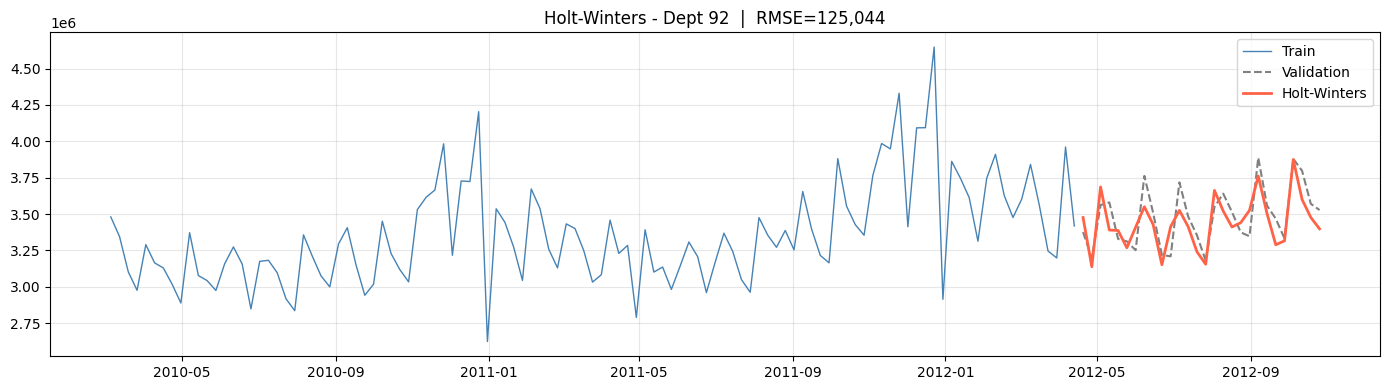


  DEPT 95 - Holt-Winters
    Holt-Winters (add,add)       MAE=      89,717  RMSE=     118,524  MAPE=2.71%


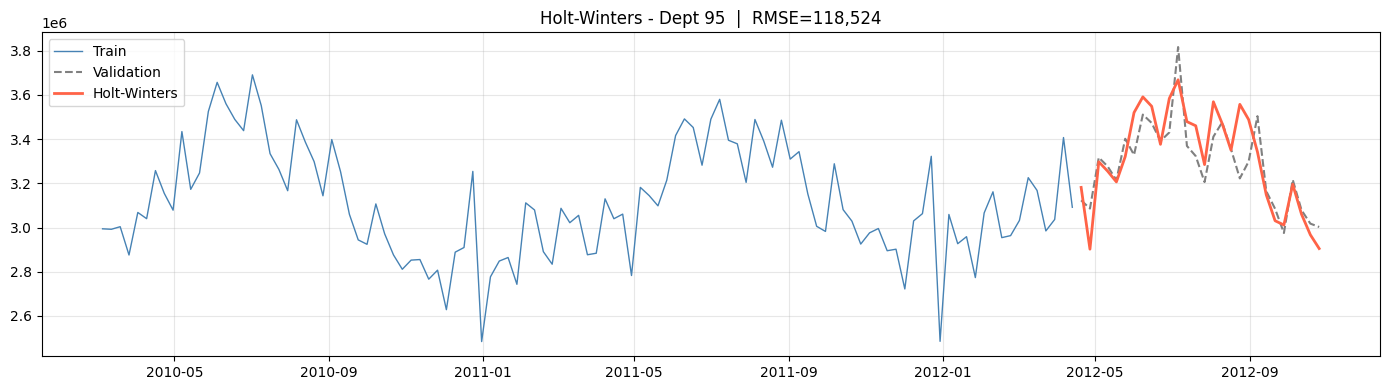


  DEPT 38 - Holt-Winters
    Holt-Winters (add,add)       MAE=     167,518  RMSE=     195,291  MAPE=6.25%


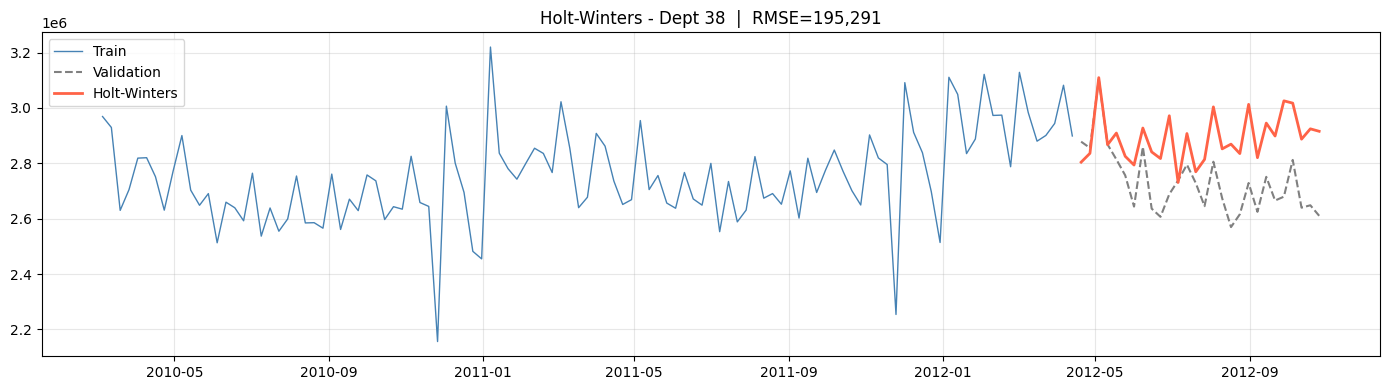

In [ ]:
for DEPT in TOP_3_DEPTS:
    print(f"\n{'='*60}")
    print(f"  DEPT {DEPT} - Holt-Winters")
    print(f"{'='*60}")

    sales_tr  = STATE[DEPT]['sales_tr']
    sales_val = STATE[DEPT]['sales_val']
    n_val     = len(sales_val)

    hw = ExponentialSmoothing(
        sales_tr, trend='add', seasonal='add', seasonal_periods=52
    ).fit(optimized=True)

    hw_pred       = hw.forecast(steps=n_val)
    hw_pred.index = sales_val.index
    m             = compute_metrics(sales_val.values, hw_pred.values, "Holt-Winters (add,add)")

    # Truc quan hoa
    plt.figure(figsize=(14, 4))
    plt.plot(sales_tr.index,  sales_tr.values,  color='steelblue',
             label='Train',      linewidth=1)
    plt.plot(sales_val.index, sales_val.values, color='gray',
             label='Validation', linewidth=1.5, linestyle='--')
    plt.plot(hw_pred.index,   hw_pred.values,   color='tomato',
             label='Holt-Winters', linewidth=2)
    plt.title(f"Holt-Winters - Dept {DEPT}  |  RMSE={m['RMSE']:,.0f}")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    STATE[DEPT]['hw_model']    = hw
    STATE[DEPT]['metrics_hw']  = m
    STATE[DEPT]['hw_pred']     = hw_pred

### **Bước 11: ARIMA (grid search AIC)**


  DEPT 92 - ARIMA (grid search AIC)
  Su dung d=1 (tu ket qua ADF+KPSS - Buoc 7)
  Grid search p=[0, 4], q=[0, 4] ...
  Ket qua grid search: ARIMA(2, 1, 3)  AIC=3105.66
    ARIMA(2, 1, 3)               MAE=     167,543  RMSE=     200,661  MAPE=4.85%


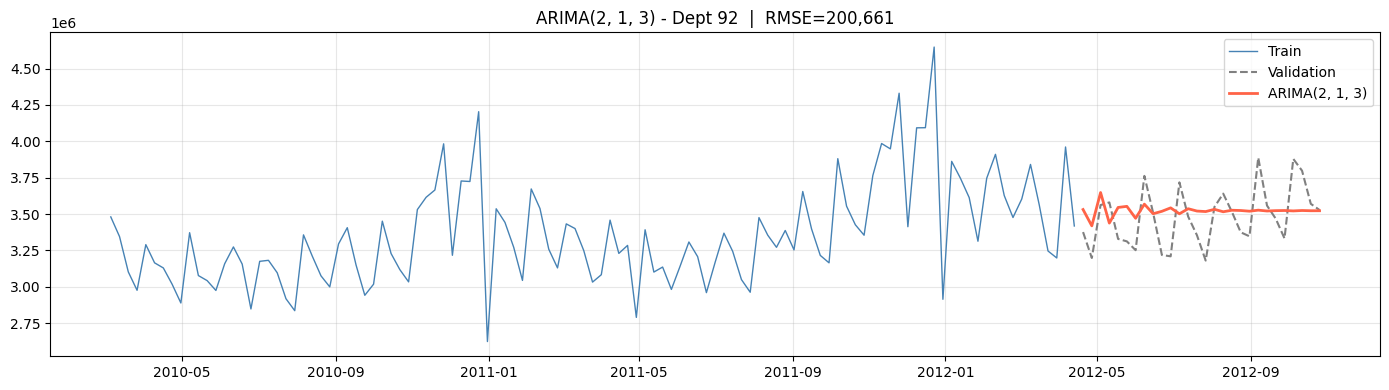


  DEPT 95 - ARIMA (grid search AIC)
  Su dung d=0 (tu ket qua ADF+KPSS - Buoc 7)
  Grid search p=[0, 4], q=[0, 4] ...
  Ket qua grid search: ARIMA(2, 0, 3)  AIC=2991.93
    ARIMA(2, 0, 3)               MAE=     138,679  RMSE=     184,475  MAPE=4.06%


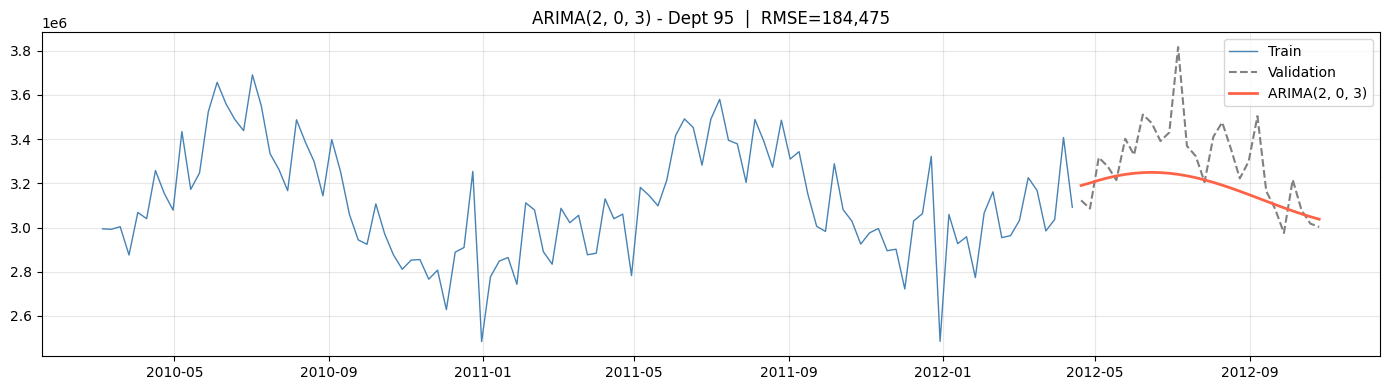


  DEPT 38 - ARIMA (grid search AIC)
  Su dung d=1 (tu ket qua ADF+KPSS - Buoc 7)
  Grid search p=[0, 4], q=[0, 4] ...
  Ket qua grid search: ARIMA(2, 1, 3)  AIC=2990.30
    ARIMA(2, 1, 3)               MAE=     174,935  RMSE=     194,116  MAPE=6.50%


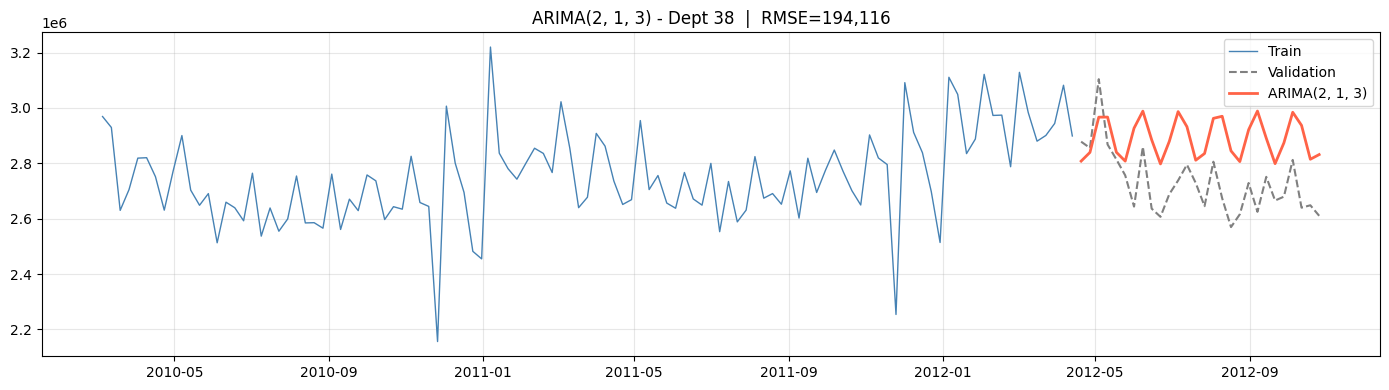

In [ ]:
for DEPT in TOP_3_DEPTS:
    print(f"\n{'='*60}")
    print(f"  DEPT {DEPT} - ARIMA (grid search AIC)")
    print(f"{'='*60}")

    sales_tr  = STATE[DEPT]['sales_tr']
    sales_val = STATE[DEPT]['sales_val']
    d_order   = STATE[DEPT]['d_order']   # lay tu ket qua ADF+KPSS (Buoc 7)
    n_val     = len(sales_val)

    print(f"  Su dung d={d_order} (tu ket qua ADF+KPSS - Buoc 7)")
    print(f"  Grid search p=[0, 4], q=[0, 4] ...")

    best_aic   = np.inf
    best_order = (1, d_order, 1)   # fallback an toan

    for p in range(0, 5):
        for q in range(0, 5):
            try:
                m = ARIMA(sales_tr, order=(p, d_order, q)).fit()
                if m.aic < best_aic:
                    best_aic   = m.aic
                    best_order = (p, d_order, q)
            except Exception:
                continue

    print(f"  Ket qua grid search: ARIMA{best_order}  AIC={best_aic:.2f}")

    arima_fit        = ARIMA(sales_tr, order=best_order).fit()
    arima_pred       = arima_fit.forecast(steps=n_val)
    arima_pred.index = sales_val.index
    m = compute_metrics(sales_val.values, arima_pred.values,
                        f"ARIMA{best_order}")

    # Truc quan hoa
    plt.figure(figsize=(14, 4))
    plt.plot(sales_tr.index,  sales_tr.values,   color='steelblue',
             label='Train',       linewidth=1)
    plt.plot(sales_val.index, sales_val.values,  color='gray',
             label='Validation',  linewidth=1.5, linestyle='--')
    plt.plot(arima_pred.index, arima_pred.values, color='tomato',
             label=f'ARIMA{best_order}', linewidth=2)
    plt.title(f"ARIMA{best_order} - Dept {DEPT}  |  RMSE={m['RMSE']:,.0f}")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    STATE[DEPT]['arima_model']   = arima_fit
    STATE[DEPT]['arima_order']   = best_order
    STATE[DEPT]['metrics_arima'] = m
    STATE[DEPT]['arima_pred']    = arima_pred

### **Bước 12: Mô hình XGBoost**


  DEPT 92 - XGBoost
    XGBoost                      MAE=     102,039  RMSE=     122,190  MAPE=2.89%


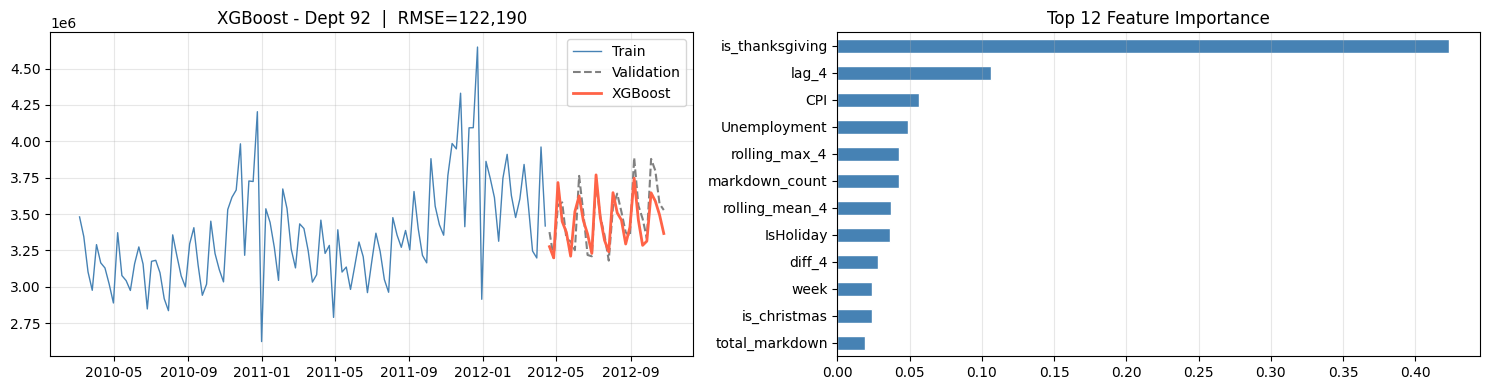


  DEPT 95 - XGBoost
    XGBoost                      MAE=      58,324  RMSE=      90,132  MAPE=1.71%


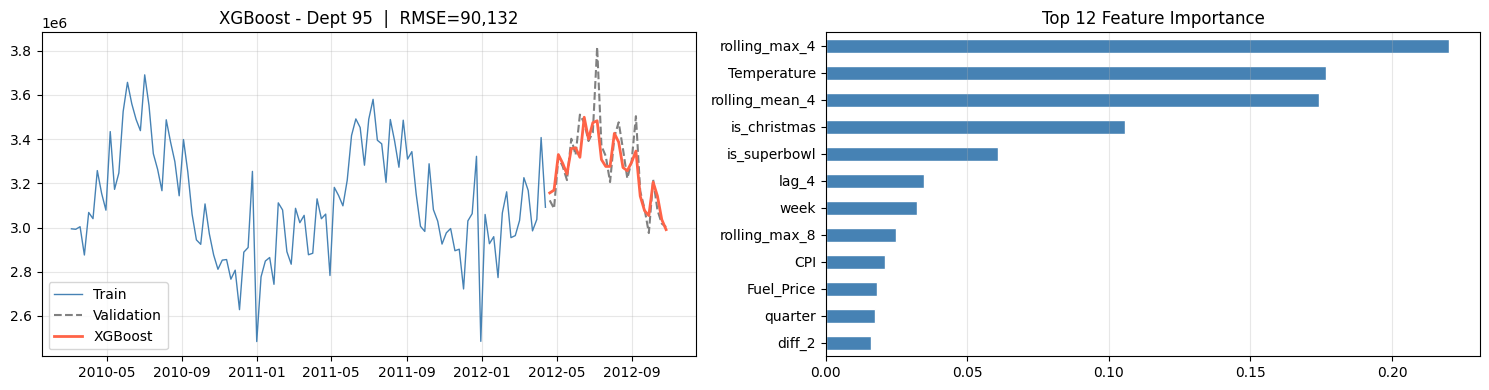


  DEPT 38 - XGBoost
    XGBoost                      MAE=     102,503  RMSE=     127,122  MAPE=3.83%


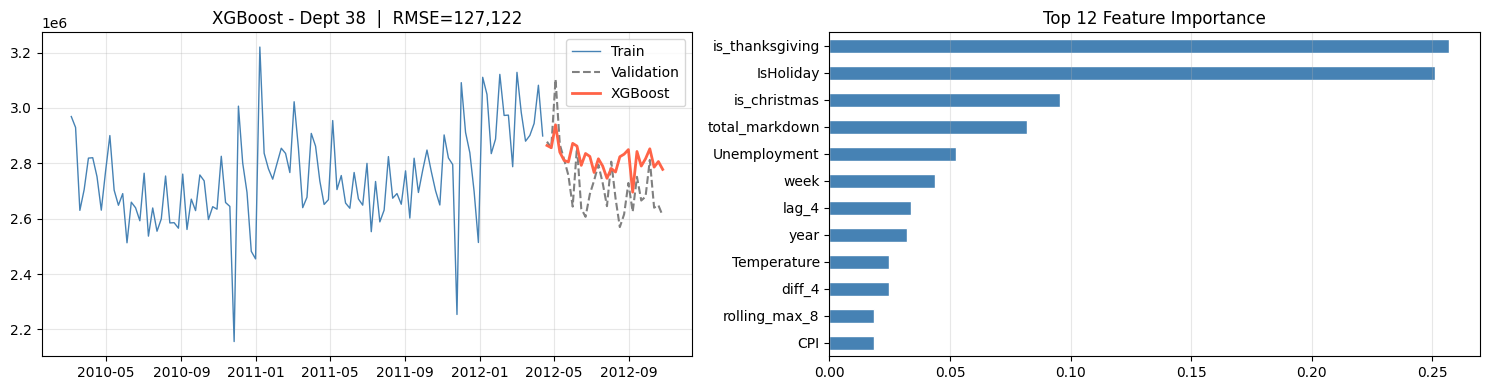

In [ ]:
for DEPT in TOP_3_DEPTS:
    print(f"\n{'='*60}")
    print(f"  DEPT {DEPT} - XGBoost")
    print(f"{'='*60}")

    X_tr  = STATE[DEPT]['X_tr'];  y_tr  = STATE[DEPT]['y_tr']
    X_val = STATE[DEPT]['X_val']; y_val = STATE[DEPT]['y_val']

    xgb = XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        objective='reg:squarederror', random_state=42, n_jobs=-1
    )
    xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    xgb_pred = xgb.predict(X_val)
    m        = compute_metrics(y_val.values, xgb_pred, "XGBoost")

    # Feature importance
    imp = pd.Series(xgb.feature_importances_,
                    index=STATE[DEPT]['fc']).sort_values(ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(STATE[DEPT]['sales_tr'].index,
                 STATE[DEPT]['sales_tr'].values,
                 color='steelblue', label='Train', linewidth=1)
    axes[0].plot(STATE[DEPT]['sales_val'].index,
                 STATE[DEPT]['sales_val'].values,
                 color='gray', label='Validation', linewidth=1.5, linestyle='--')
    axes[0].plot(STATE[DEPT]['X_val'].index, xgb_pred,
                 color='tomato', label='XGBoost', linewidth=2)
    axes[0].set_title(f"XGBoost - Dept {DEPT}  |  RMSE={m['RMSE']:,.0f}")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    imp.head(12).plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
    axes[1].invert_yaxis()
    axes[1].set_title("Top 12 Feature Importance")
    axes[1].grid(True, alpha=0.3, axis='x')
    plt.tight_layout(); plt.show()

    STATE[DEPT]['xgb_model']    = xgb
    STATE[DEPT]['metrics_xgb']  = m
    STATE[DEPT]['xgb_pred']     = xgb_pred
    STATE[DEPT]['xgb_params']   = {'n_estimators': 500,
                                   'learning_rate': 0.05, 'max_depth': 5}

### **Bước 13: Tinh chỉnh Hyperparameter**

In [ ]:
for DEPT in TOP_3_DEPTS:
    print(f"\n{'='*60}")
    print(f"  DEPT {DEPT} - Tinh chinh hyperparameter")
    print(f"{'='*60}")

    sales_tr  = STATE[DEPT]['sales_tr']
    sales_val = STATE[DEPT]['sales_val']
    X_tr      = STATE[DEPT]['X_tr'];  y_tr  = STATE[DEPT]['y_tr']
    X_val     = STATE[DEPT]['X_val']; y_val = STATE[DEPT]['y_val']
    n_val     = len(sales_val)

    # --- Tinh chinh Holt-Winters ---
    print("  Holt-Winters configs:")
    hw_best_rmse = STATE[DEPT]['metrics_hw']['RMSE']
    hw_best_fit  = STATE[DEPT]['hw_model']
    hw_best_cfg  = {'trend': 'add', 'seasonal': 'add'}
    for cfg in [{'trend': 'add', 'seasonal': 'add'},
                {'trend': 'add', 'seasonal': 'mul'}]:
        try:
            m = ExponentialSmoothing(
                sales_tr, seasonal_periods=52, **cfg
            ).fit(optimized=True)
            p = m.forecast(steps=n_val)
            r = np.sqrt(np.mean((sales_val.values - p.values) ** 2))
            tag = " <- tot nhat" if r < hw_best_rmse else ""
            print(f"    {str(cfg):<40} RMSE={r:>12,.0f}{tag}")
            if r < hw_best_rmse:
                hw_best_rmse = r
                hw_best_fit  = m
                hw_best_cfg  = cfg
        except Exception:
            continue

    # --- Tinh chinh XGBoost ---
    print("  XGBoost params:")
    xgb_best_rmse   = STATE[DEPT]['metrics_xgb']['RMSE']
    xgb_best_model  = STATE[DEPT]['xgb_model']
    xgb_best_params = STATE[DEPT]['xgb_params']
    for params in [
        {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4},
        {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 5},
        {'n_estimators': 700, 'learning_rate': 0.02, 'max_depth': 6},
    ]:
        m = XGBRegressor(**params, subsample=0.8, colsample_bytree=0.8,
                         objective='reg:squarederror',
                         random_state=42, n_jobs=-1)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        p = m.predict(X_val)
        r = np.sqrt(np.mean((y_val.values - p) ** 2))
        tag = " <- tot nhat" if r < xgb_best_rmse else ""
        print(f"    {str(params):<55} RMSE={r:>12,.0f}{tag}")
        if r < xgb_best_rmse:
            xgb_best_rmse   = r
            xgb_best_model  = m
            xgb_best_params = params

    # Luu phien ban tot nhat (goc vs tuned)
    hw_tuned_pred       = hw_best_fit.forecast(steps=n_val)
    hw_tuned_pred.index = sales_val.index
    metrics_hw_best     = compute_metrics(sales_val.values,
                                          hw_tuned_pred.values, "Holt-Winters best")

    xgb_tuned_pred  = xgb_best_model.predict(X_val)
    metrics_xgb_best = compute_metrics(y_val.values,
                                       xgb_tuned_pred, "XGBoost best")

    STATE[DEPT].update({
        'hw_best_fit'     : hw_best_fit,
        'hw_best_cfg'     : hw_best_cfg,
        'metrics_hw_best' : metrics_hw_best,
        'xgb_best_model'  : xgb_best_model,
        'xgb_best_params' : xgb_best_params,
        'metrics_xgb_best': metrics_xgb_best,
    })


  DEPT 92 - Tinh chinh hyperparameter
  Holt-Winters configs:
    {'trend': 'add', 'seasonal': 'add'}      RMSE=     125,044
    {'trend': 'add', 'seasonal': 'mul'}      RMSE=     123,752 <- tot nhat
  XGBoost params:
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4} RMSE=     125,019
    {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 5} RMSE=     124,355
    {'n_estimators': 700, 'learning_rate': 0.02, 'max_depth': 6} RMSE=     132,228
    Holt-Winters best            MAE=      93,382  RMSE=     123,752  MAPE=2.71%
    XGBoost best                 MAE=     102,039  RMSE=     122,190  MAPE=2.89%

  DEPT 95 - Tinh chinh hyperparameter
  Holt-Winters configs:
    {'trend': 'add', 'seasonal': 'add'}      RMSE=     118,524
    {'trend': 'add', 'seasonal': 'mul'}      RMSE=     118,769
  XGBoost params:
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4} RMSE=      93,257
    {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 5} RMSE=      91,3

# **PHASE 6: SO SÁNH VÀ TRIỂN KHAI**

### **Bước 14: So sánh & chọn mô hình tốt nhất**


  DEPT 92 - So sanh & Chon mo hinh
            model            MAE           RMSE      MAPE
1         XGBoost  102038.981071  122190.059214  2.894498
2    Holt-Winters   93381.504404  123751.585185  2.705367
3  ARIMA(2, 1, 3)  167542.956235  200661.431162  4.847022


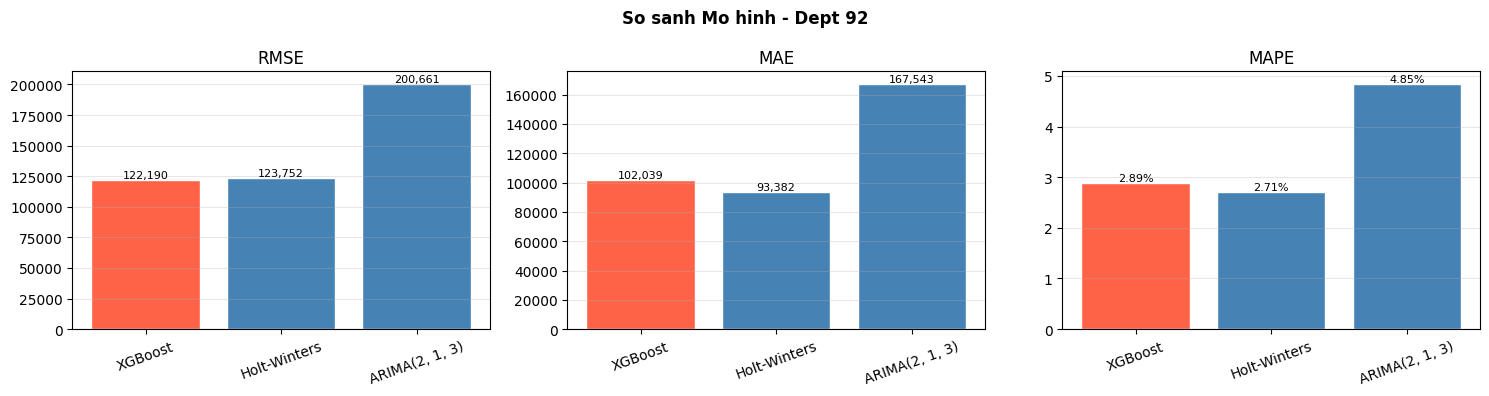


  => Mo hinh tot nhat: XGBoost (RMSE=122,190, MAPE=2.89%)

  --- Tham so mo hinh tot nhat ---
    n_estimators     : 500
    learning_rate    : 0.05
    max_depth        : 5
    subsample        : 0.8  (co dinh)
    colsample_bytree : 0.8  (co dinh)

  DEPT 95 - So sanh & Chon mo hinh
            model            MAE           RMSE      MAPE
1         XGBoost   58324.260714   90132.103943  1.713775
2    Holt-Winters   89716.934934  118524.211743  2.712578
3  ARIMA(2, 0, 3)  138678.632467  184475.026615  4.062200


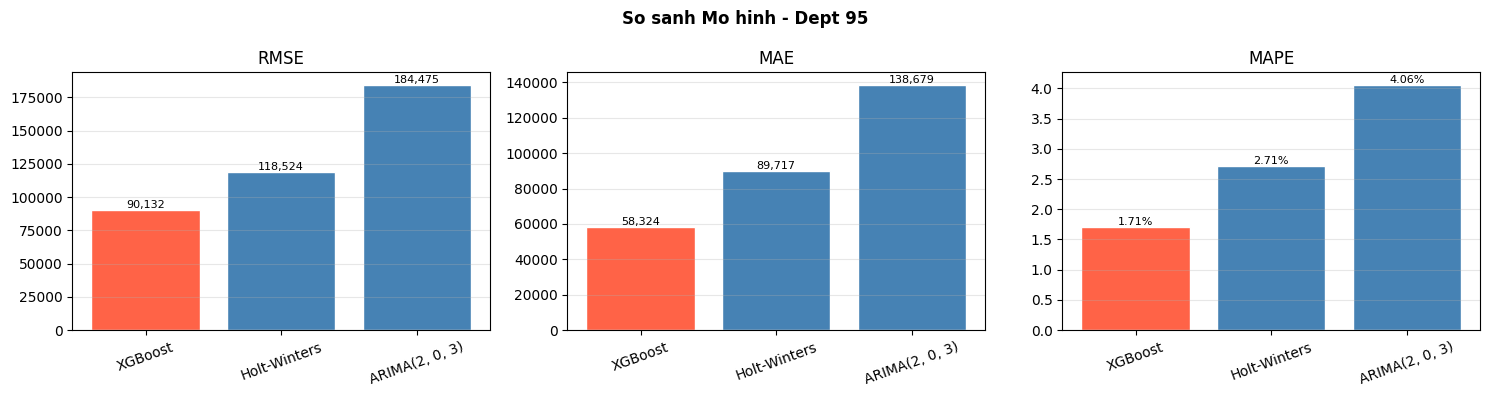


  => Mo hinh tot nhat: XGBoost (RMSE=90,132, MAPE=1.71%)

  --- Tham so mo hinh tot nhat ---
    n_estimators     : 500
    learning_rate    : 0.05
    max_depth        : 5
    subsample        : 0.8  (co dinh)
    colsample_bytree : 0.8  (co dinh)

  DEPT 38 - So sanh & Chon mo hinh
            model            MAE           RMSE      MAPE
1         XGBoost   96630.885357  120530.739308  3.608073
2    Holt-Winters  151033.209980  176849.100890  5.631908
3  ARIMA(2, 1, 3)  174934.821671  194116.404280  6.496447


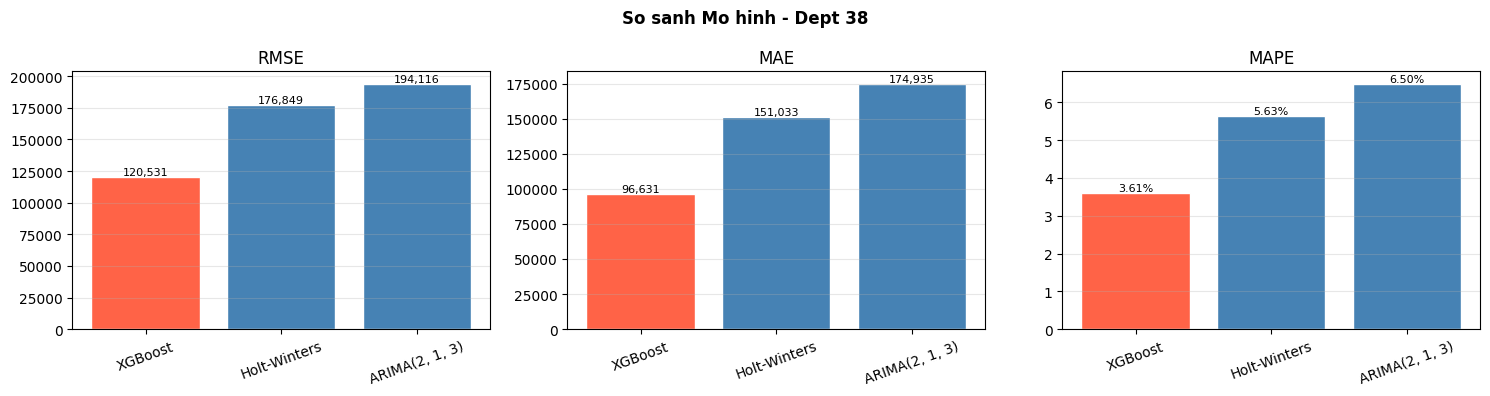


  => Mo hinh tot nhat: XGBoost (RMSE=120,531, MAPE=3.61%)

  --- Tham so mo hinh tot nhat ---
    n_estimators     : 700
    learning_rate    : 0.02
    max_depth        : 6
    subsample        : 0.8  (co dinh)
    colsample_bytree : 0.8  (co dinh)


In [ ]:
for DEPT in TOP_3_DEPTS:
    print(f"\n{'='*60}")
    print(f"  DEPT {DEPT} - So sanh & Chon mo hinh")
    print(f"{'='*60}")

    rows = [
        {**STATE[DEPT]['metrics_hw_best'],  'model': 'Holt-Winters'},
        {**STATE[DEPT]['metrics_arima'],    'model': f"ARIMA{STATE[DEPT]['arima_order']}"},
        {**STATE[DEPT]['metrics_xgb_best'], 'model': 'XGBoost'},
    ]
    df_cmp = (pd.DataFrame(rows)
                .sort_values('RMSE')
                .reset_index(drop=True))
    df_cmp.index += 1
    print(df_cmp[['model','MAE','RMSE','MAPE']].to_string())

    # Bieu do so sanh
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"So sanh Mo hinh - Dept {DEPT}", fontsize=12, fontweight='bold')
    for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE']):
        clrs = ['tomato' if i == 0 else 'steelblue'
                for i in range(len(df_cmp))]
        bars = ax.bar(df_cmp['model'], df_cmp[metric],
                      color=clrs, edgecolor='white')
        ax.set_title(metric)
        ax.tick_params(axis='x', rotation=20)
        ax.grid(True, alpha=0.3, axis='y')
        for bar, val in zip(bars, df_cmp[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f'{val:,.0f}' if metric != 'MAPE' else f'{val:.2f}%',
                    ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.show()

    best_name = df_cmp.iloc[0]['model']
    print(f"\n  => Mo hinh tot nhat: {best_name} "
          f"(RMSE={df_cmp.iloc[0]['RMSE']:,.0f}, "
          f"MAPE={df_cmp.iloc[0]['MAPE']:.2f}%)")

    # --- In chi tiet tham so cua mo hinh tot nhat ---
    print(f"\n  --- Tham so mo hinh tot nhat ---")
    if 'XGBoost' in best_name:
        params = STATE[DEPT]['xgb_best_params']
        print(f"    n_estimators     : {params['n_estimators']}")
        print(f"    learning_rate    : {params['learning_rate']}")
        print(f"    max_depth        : {params['max_depth']}")
        print(f"    subsample        : 0.8  (co dinh)")
        print(f"    colsample_bytree : 0.8  (co dinh)")

    elif 'Holt-Winters' in best_name:
        cfg = STATE[DEPT]['hw_best_cfg']
        print(f"    trend            : {cfg['trend']}")
        print(f"    seasonal         : {cfg['seasonal']}")
        print(f"    seasonal_periods : 52")
        print(f"    optimized        : True")

    else:   # ARIMA
        order = STATE[DEPT]['arima_order']
        print(f"    p (AR order)     : {order[0]}")
        print(f"    d (differencing) : {order[1]}")
        print(f"    q (MA order)     : {order[2]}")

    STATE[DEPT]['df_cmp']          = df_cmp
    STATE[DEPT]['best_model_name'] = best_name

### **Bước 15: Retrain + Recursive Forecast test**


  DEPT 92 - Retrain & Du bao Test
  So tuan test: 39
  Retrain voi mo hinh: XGBoost


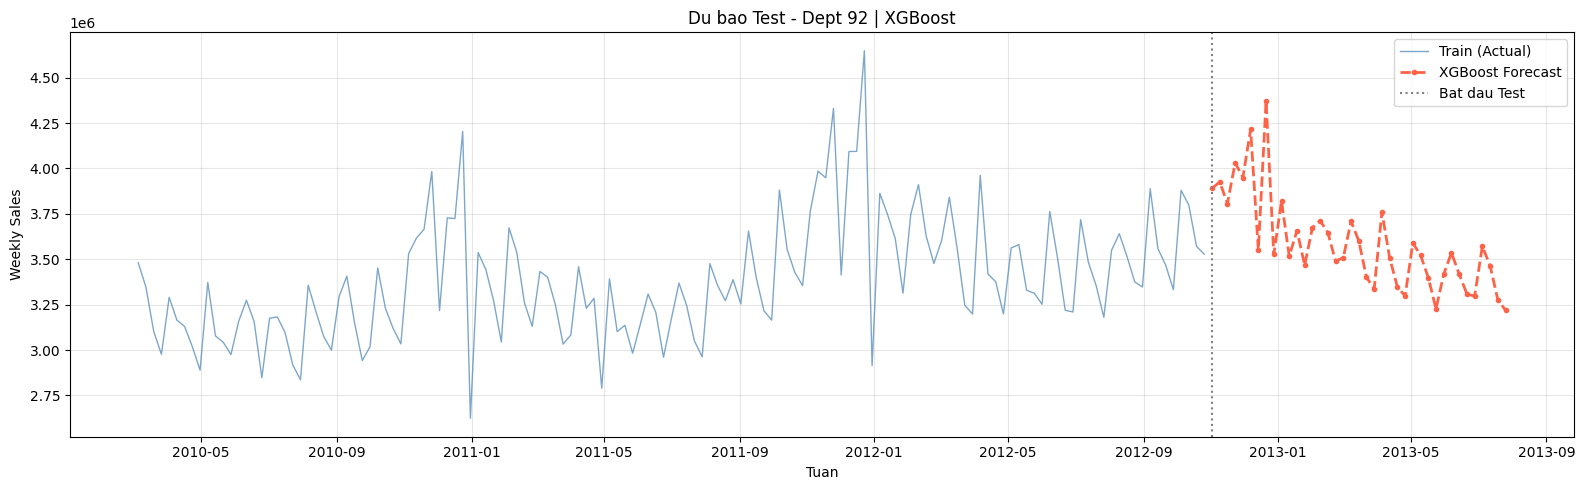


  DEPT 95 - Retrain & Du bao Test
  So tuan test: 39
  Retrain voi mo hinh: XGBoost


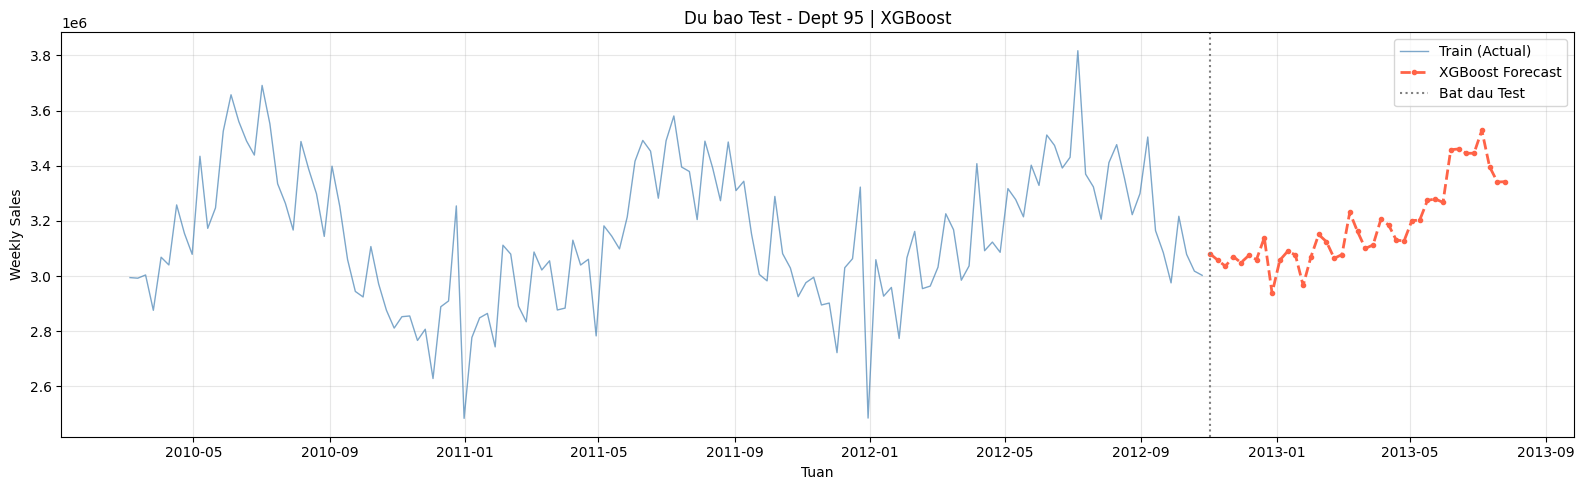


  DEPT 38 - Retrain & Du bao Test
  So tuan test: 39
  Retrain voi mo hinh: XGBoost


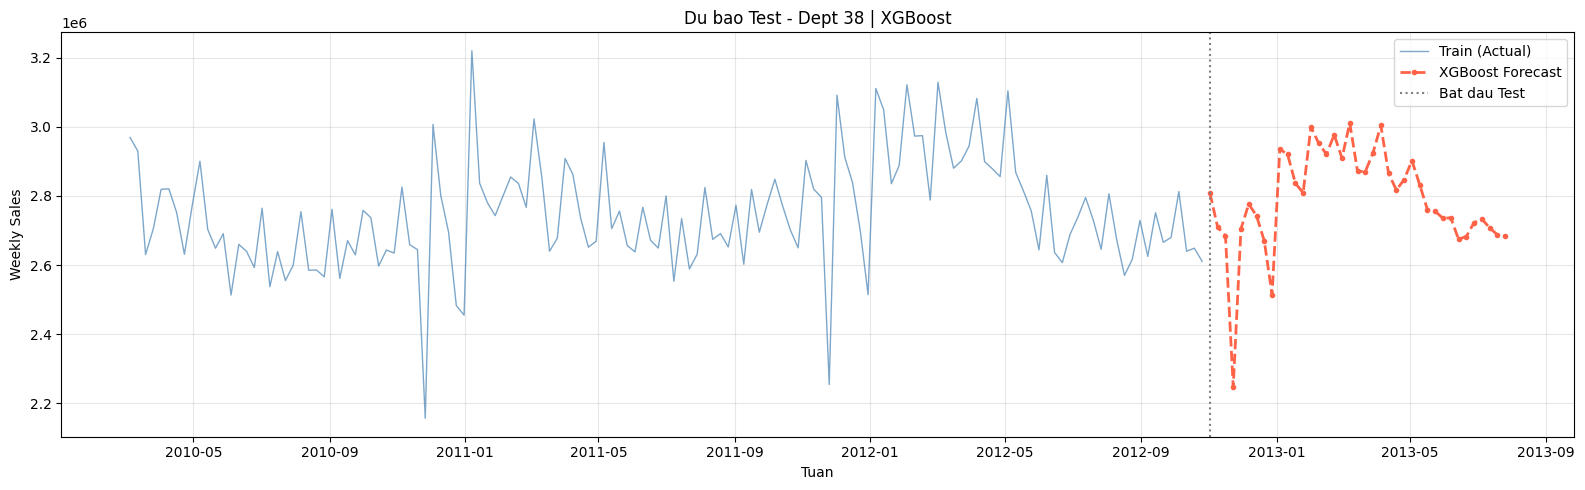

In [ ]:
for DEPT in TOP_3_DEPTS:
    print(f"\n{'='*60}")
    print(f"  DEPT {DEPT} - Retrain & Du bao Test")
    print(f"{'='*60}")

    df_clean      = STATE[DEPT]['df_clean']
    best_name     = STATE[DEPT]['best_model_name']
    fc            = STATE[DEPT]['fc']
    d_order       = STATE[DEPT]['d_order']

    # Chuan bi tap test
    df_test = (test[test['Dept'] == DEPT]
               .copy()
               .merge(features, on=['Store','Date','IsHoliday'], how='left')
               .merge(stores,   on='Store', how='left')
               .sort_values('Date')
               .reset_index(drop=True))
    df_test.set_index('Date', inplace=True)

    df_test_agg = df_test.groupby(df_test.index).agg({
        'IsHoliday'   : 'max',
        'Temperature' : 'mean',
        'Fuel_Price'  : 'mean',
        'CPI'         : 'mean',
        'Unemployment': 'mean',
        **{c: 'sum' for c in MARKDOWN_COLS},
    })
    df_test_agg = add_time_holiday_promo_features(df_test_agg)

    print(f"  So tuan test: {len(df_test_agg)}")
    print(f"  Retrain voi mo hinh: {best_name}")

    if 'XGBoost' in best_name:
        params = STATE[DEPT]['xgb_best_params']
        model  = XGBRegressor(**params, subsample=0.8, colsample_bytree=0.8,
                              objective='reg:squarederror',
                              random_state=42, n_jobs=-1)
        model.fit(df_clean[fc], df_clean[TARGET_COL], verbose=False)
        history      = list(df_clean[TARGET_COL].values)
        test_preds   = recursive_forecast_xgb(history, df_test_agg, model, fc)

    elif 'Holt-Winters' in best_name:
        cfg   = STATE[DEPT]['hw_best_cfg']
        model = ExponentialSmoothing(
            df_clean[TARGET_COL], seasonal_periods=52, **cfg
        ).fit(optimized=True)
        test_preds = list(model.forecast(steps=len(df_test_agg)).values)

    else:   # ARIMA
        order = STATE[DEPT]['arima_order']
        model = ARIMA(df_clean[TARGET_COL], order=order).fit()
        test_preds = list(model.forecast(steps=len(df_test_agg)).values)

    df_test_agg['Predicted_Sales'] = test_preds

    # Truc quan hoa
    plt.figure(figsize=(16, 5))
    plt.plot(df_clean.index, df_clean[TARGET_COL],
             label="Train (Actual)", color='steelblue', linewidth=1, alpha=0.7)
    plt.plot(df_test_agg.index, df_test_agg['Predicted_Sales'],
             label=f"{best_name} Forecast", color='tomato',
             linestyle='--', linewidth=2, marker='o', markersize=3)
    plt.axvline(x=df_test_agg.index[0], color='gray',
                linestyle=':', linewidth=1.5, label="Bat dau Test")
    plt.title(f"Du bao Test - Dept {DEPT} | {best_name}")
    plt.xlabel("Tuan"); plt.ylabel("Weekly Sales")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    STATE[DEPT]['df_test_agg'] = df_test_agg
    STATE[DEPT]['final_model'] = model

### **Bước 16: Tổng hợp kết quả**

  TONG HOP KET QUA - TOP 3 DEPARTMENTS

--- Mo hinh tot nhat moi Department ---
 Department Mo hinh tot nhat      MAE     RMSE  MAPE (%)
         92          XGBoost 102039.0 122190.0      2.89
         95          XGBoost  58324.0  90132.0      1.71
         38          XGBoost  96631.0 120531.0      3.61


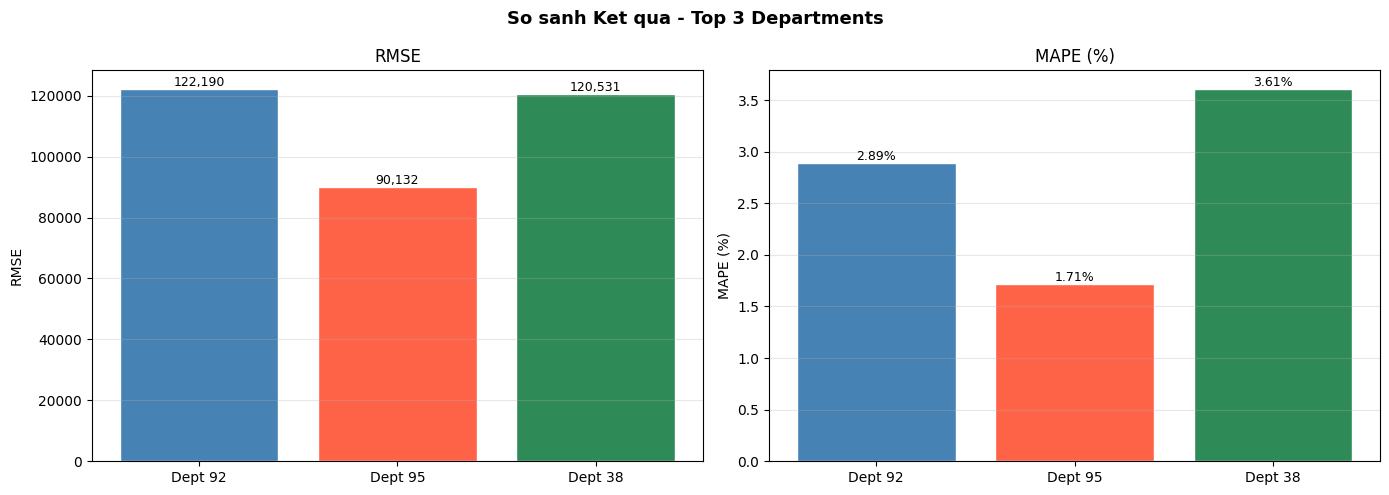

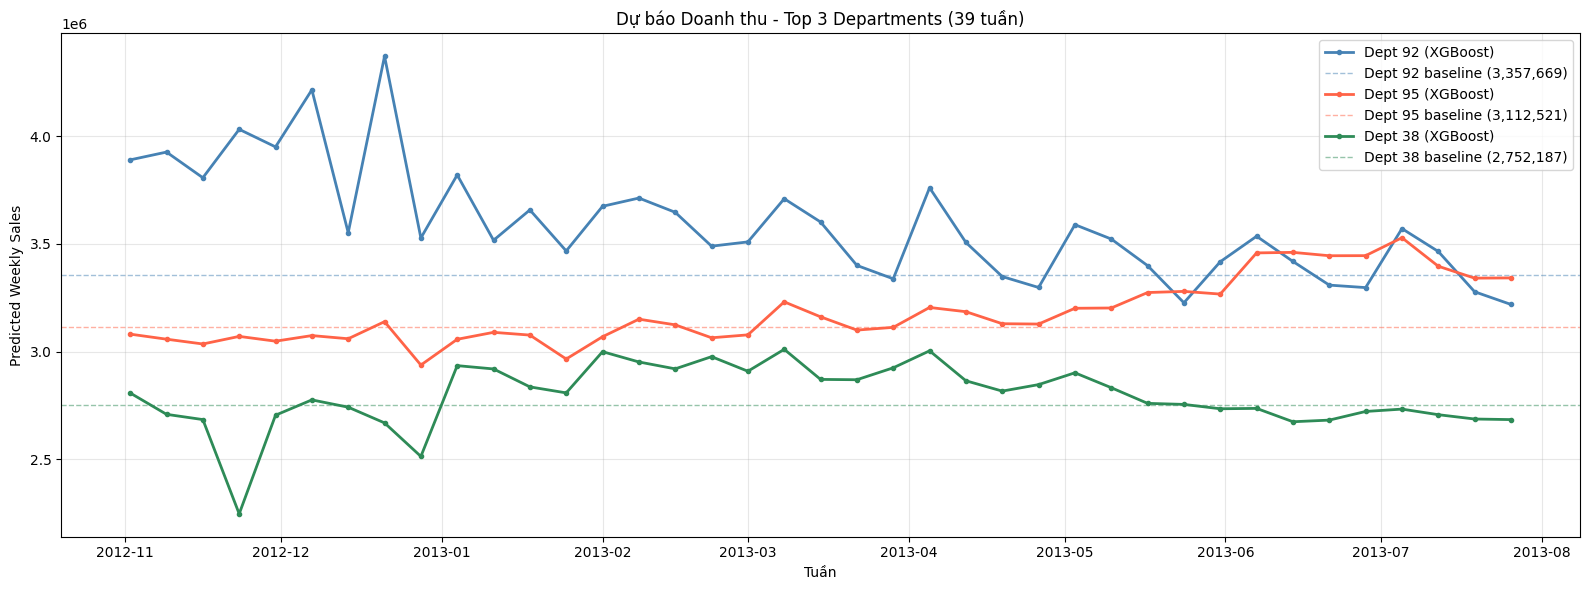

In [ ]:
print("=" * 70)
print("  TONG HOP KET QUA - TOP 3 DEPARTMENTS")
print("=" * 70)

summary_rows = []
for DEPT in TOP_3_DEPTS:
    r = STATE[DEPT]
    summary_rows.append({
        'Department'      : DEPT,
        'Mo hinh tot nhat': r['best_model_name'],
        'MAE'             : round(r['df_cmp'].iloc[0]['MAE'],  0),
        'RMSE'            : round(r['df_cmp'].iloc[0]['RMSE'], 0),
        'MAPE (%)'        : round(r['df_cmp'].iloc[0]['MAPE'], 2),
    })
df_summary = pd.DataFrame(summary_rows)
print("\n--- Mo hinh tot nhat moi Department ---")
print(df_summary.to_string(index=False))

# RMSE & MAPE tong hop
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("So sanh Ket qua - Top 3 Departments",
             fontsize=13, fontweight='bold')
dept_labels = [f"Dept {d}" for d in TOP_3_DEPTS]
dept_clrs   = ['steelblue', 'tomato', 'seagreen']

for ax, metric, ylabel in zip(
    axes,
    ['RMSE', 'MAPE (%)'],
    ['RMSE', 'MAPE (%)']
):
    vals = [STATE[d]['df_cmp'].iloc[0]['RMSE' if metric == 'RMSE' else 'MAPE']
            for d in TOP_3_DEPTS]
    bars = ax.bar(dept_labels, vals, color=dept_clrs, edgecolor='white')
    ax.set_title(metric); ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:,.0f}' if metric == 'RMSE' else f'{val:.2f}%',
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

# Du bao 3 dept tren cung 1 do thi
plt.figure(figsize=(16, 6))
for i, DEPT in enumerate(TOP_3_DEPTS):
    df_fc      = STATE[DEPT]['df_test_agg']
    train_mean = STATE[DEPT]['sales_tr'].mean()   # baseline từ train

    plt.plot(df_fc.index, df_fc['Predicted_Sales'],
             label=f"Dept {DEPT} ({STATE[DEPT]['best_model_name']})",
             color=dept_clrs[i], linewidth=2, marker='o', markersize=3)

    plt.axhline(y=train_mean, color=dept_clrs[i],
                linestyle='--', linewidth=1, alpha=0.5,
                label=f"Dept {DEPT} baseline ({train_mean:,.0f})")

plt.title("Dự báo Doanh thu - Top 3 Departments (39 tuần)")
plt.xlabel("Tuần"); plt.ylabel("Predicted Weekly Sales")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### **Bước 17: Insight tồn kho cho từng Dept**


  DEPT 92 - Phan loai muc nhu cau
  Doanh thu TB       :       3,588,936
  Cao nhat           :       4,370,540 (2012-12-21)
  Thap nhat          :       3,218,958 (2013-07-26)
  Nguong thap (p25)  :       3,124,209
  Nguong cao (p75)   :       3,537,357

            Predicted_Sales   Demand_Level
Date                                      
2012-11-02       3889715.50    High Demand
2012-11-09       3925838.25    High Demand
2012-11-16       3806765.00    High Demand
2012-11-23       4031349.25    High Demand
2012-11-30       3949887.25    High Demand
2012-12-07       4214637.00    High Demand
2012-12-14       3551818.50    High Demand
2012-12-21       4370540.50    High Demand
2012-12-28       3527345.50  Normal Demand
2013-01-04       3819852.00    High Demand
2013-01-11       3516670.00  Normal Demand
2013-01-18       3657512.75    High Demand
2013-01-25       3467120.00  Normal Demand
2013-02-01       3674288.75    High Demand
2013-02-08       3712505.50    High Demand
2013-02-15  

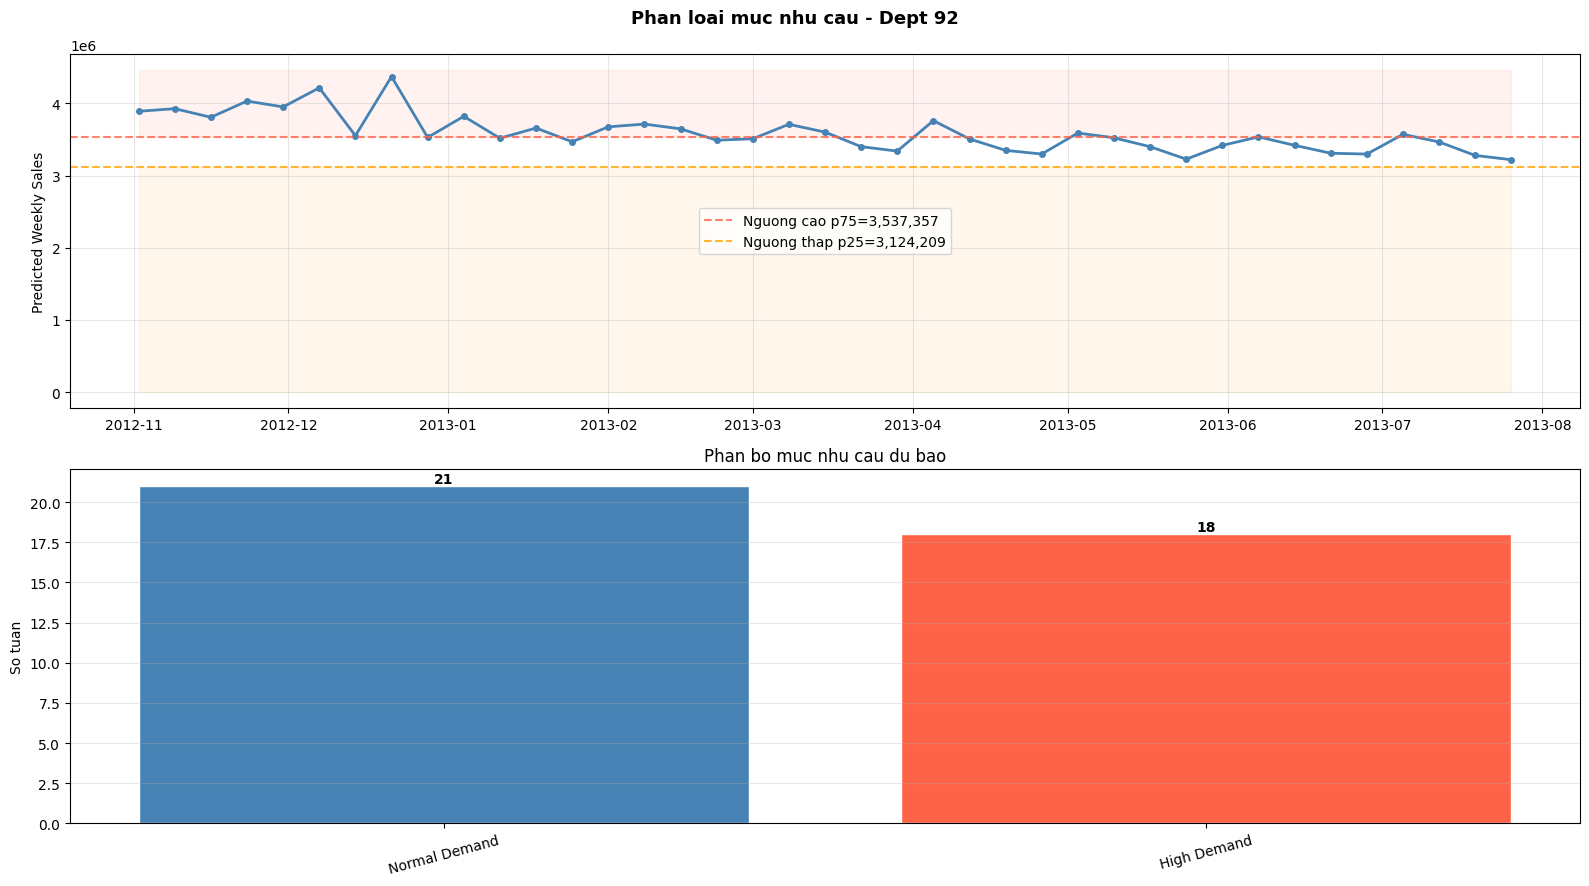


  DEPT 95 - Phan loai muc nhu cau
  Doanh thu TB       :       3,181,415
  Cao nhat           :       3,528,483 (2013-07-05)
  Thap nhat          :       2,937,839 (2012-12-28)
  Nguong thap (p25)  :       2,935,616
  Nguong cao (p75)   :       3,285,454

            Predicted_Sales   Demand_Level
Date                                      
2012-11-02       3081210.00  Normal Demand
2012-11-09       3057807.00  Normal Demand
2012-11-16       3035527.75  Normal Demand
2012-11-23       3070752.00  Normal Demand
2012-11-30       3048549.50  Normal Demand
2012-12-07       3074530.75  Normal Demand
2012-12-14       3059856.75  Normal Demand
2012-12-21       3139097.25  Normal Demand
2012-12-28       2937839.25  Normal Demand
2013-01-04       3057307.50  Normal Demand
2013-01-11       3089581.50  Normal Demand
2013-01-18       3076794.50  Normal Demand
2013-01-25       2965864.75  Normal Demand
2013-02-01       3069269.75  Normal Demand
2013-02-08       3150646.00  Normal Demand
2013-02-15  

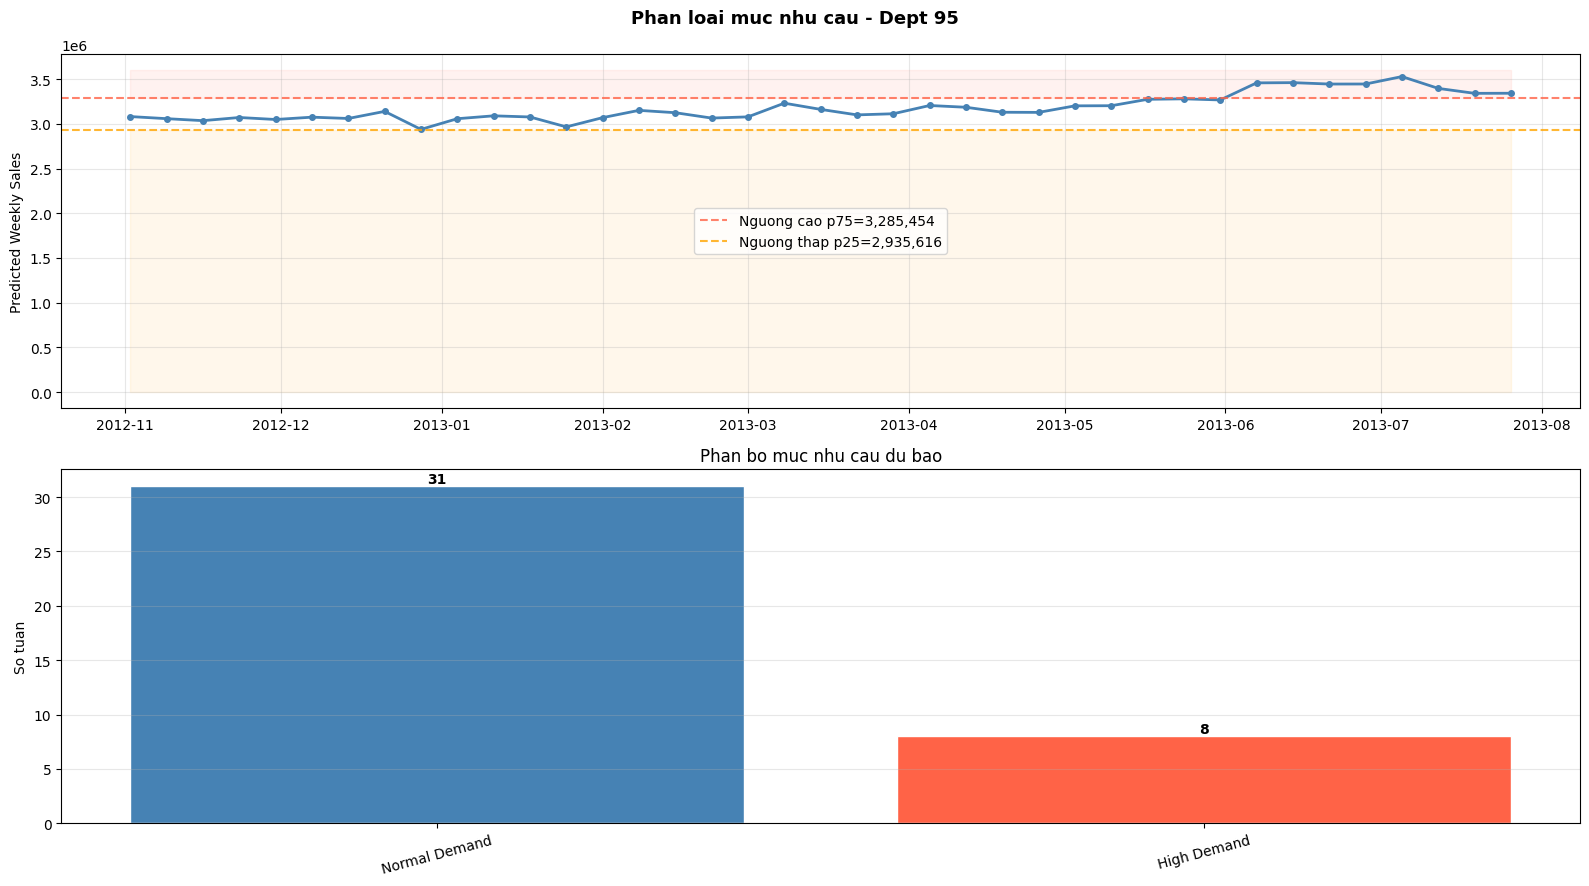


  DEPT 38 - Phan loai muc nhu cau
  Doanh thu TB       :       2,793,308
  Cao nhat           :       3,010,797 (2013-03-08)
  Thap nhat          :       2,247,558 (2012-11-23)
  Nguong thap (p25)  :       2,643,930
  Nguong cao (p75)   :       2,843,122

            Predicted_Sales   Demand_Level
Date                                      
2012-11-02       2808161.50  Normal Demand
2012-11-09       2709201.25  Normal Demand
2012-11-16       2684832.75  Normal Demand
2012-11-23       2247558.25     Low Demand
2012-11-30       2705195.00  Normal Demand
2012-12-07       2776210.50  Normal Demand
2012-12-14       2742384.00  Normal Demand
2012-12-21       2669446.50  Normal Demand
2012-12-28       2513959.00     Low Demand
2013-01-04       2935138.75    High Demand
2013-01-11       2919715.75    High Demand
2013-01-18       2836550.25  Normal Demand
2013-01-25       2808667.75  Normal Demand
2013-02-01       2999904.50    High Demand
2013-02-08       2952148.75    High Demand
2013-02-15  

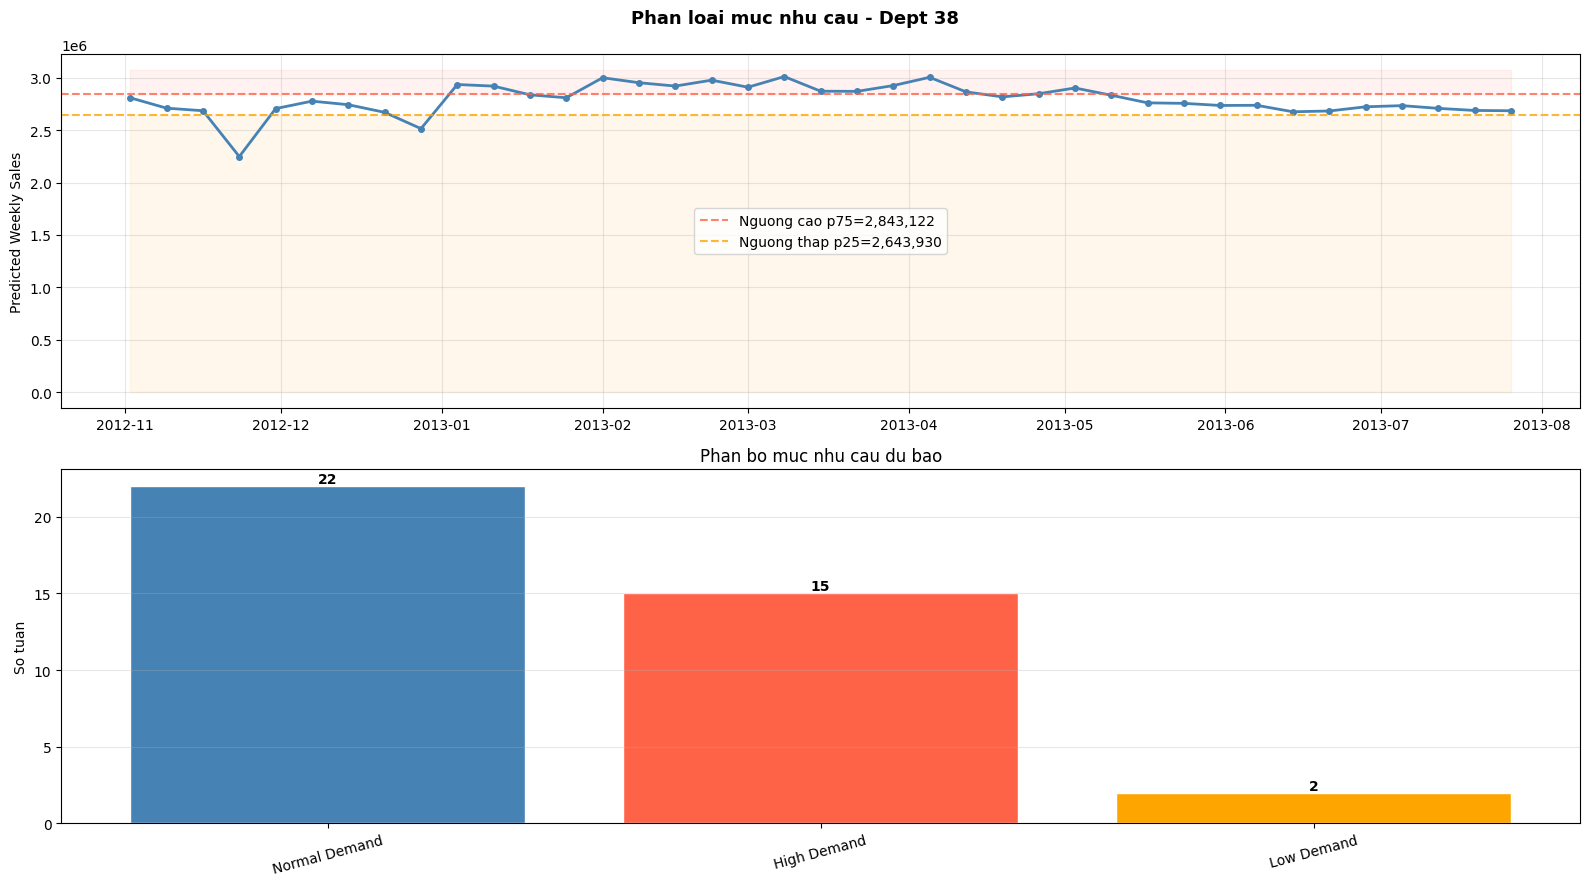

In [ ]:
def classify_demand(x, p25, p75):
    if x > p75:
        return "High Demand"
    elif x < p25:
        return "Low Demand"
    else:
        return "Normal Demand"


for DEPT in TOP_3_DEPTS:
    print(f"\n{'='*60}")
    print(f"  DEPT {DEPT} - Phan loai muc nhu cau")
    print(f"{'='*60}")

    df_fc = STATE[DEPT]['df_test_agg']

    # Percentile thresholds
    # p25 = df_fc['Predicted_Sales'].quantile(0.25)
    # p75 = df_fc['Predicted_Sales'].quantile(0.75)

    p25 = STATE[DEPT]['sales_tr'].quantile(0.25)
    p75 = STATE[DEPT]['sales_tr'].quantile(0.75)

    # Demand classification
    df_fc['Demand_Level'] = df_fc['Predicted_Sales'].apply(
        lambda x: classify_demand(x, p25, p75)
    )

    # Summary statistics
    print(f"  Doanh thu TB       : {df_fc['Predicted_Sales'].mean():>15,.0f}")
    print(f"  Cao nhat           : {df_fc['Predicted_Sales'].max():>15,.0f} "
          f"({df_fc['Predicted_Sales'].idxmax().date()})")
    print(f"  Thap nhat          : {df_fc['Predicted_Sales'].min():>15,.0f} "
          f"({df_fc['Predicted_Sales'].idxmin().date()})")
    print(f"  Nguong thap (p25)  : {p25:>15,.0f}")
    print(f"  Nguong cao (p75)   : {p75:>15,.0f}")
    print()

    print(df_fc[['Predicted_Sales', 'Demand_Level']].to_string())

    # ===================== Plot =====================
    fig, axes = plt.subplots(2, 1, figsize=(16, 9))
    fig.suptitle(f"Phan loai muc nhu cau - Dept {DEPT}", fontsize=13, fontweight='bold')

    # Forecast plot
    axes[0].plot(df_fc.index, df_fc['Predicted_Sales'],
                 color='steelblue', linewidth=2, marker='o', markersize=4)

    axes[0].axhline(y=p75, color='tomato', linestyle='--', alpha=0.8,
                    label=f"Nguong cao p75={p75:,.0f}")

    axes[0].axhline(y=p25, color='orange', linestyle='--', alpha=0.8,
                    label=f"Nguong thap p25={p25:,.0f}")

    axes[0].fill_between(df_fc.index, p75,
                         df_fc['Predicted_Sales'].max() * 1.02,
                         alpha=0.08, color='tomato')

    axes[0].fill_between(df_fc.index, 0, p25,
                         alpha=0.08, color='orange')

    axes[0].set_ylabel("Predicted Weekly Sales")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Demand distribution
    demand_counts = df_fc['Demand_Level'].value_counts()

    color_map = {
        'High Demand': 'tomato',
        'Normal Demand': 'steelblue',
        'Low Demand': 'orange'
    }

    bars = axes[1].bar(
        demand_counts.index,
        demand_counts.values,
        color=[color_map.get(x, 'gray') for x in demand_counts.index],
        edgecolor='white'
    )

    axes[1].set_ylabel("So tuan")
    axes[1].set_title("Phan bo muc nhu cau du bao")
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].grid(True, alpha=0.3, axis='y')

    for bar, val in zip(bars, demand_counts.values):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height(),
                     str(val),
                     ha='center',
                     va='bottom',
                     fontweight='bold')

    plt.tight_layout()
    plt.show()